# 0 - Helpers

In [9]:
from notebooks_function import *

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import pypsa
from collections import Counter
import os
import country_converter

vres_carriers = [
    "solar",
    "solar rooftop",
    "solar-hsat",
    "onwind",
    "offwind-ac",
    "offwind-dc",
    "offwind-float",
]

clean_carriers = [
    "green_ocgt", "adv_firm_tech", "nuclear", "allam",
    "offwind", "offwind-ac", "offwind-dc", "offwind-float", "onwind", "solar", "solar-hsat", "solar rooftop",
    "ror", "hydro", "urban central solid biomass CHP", "geothermal",
    ]

def plot_bar(df, colors, ylabel=None, title=None, figsize=(12, 6), vert_lines=True, ylim=False):
    # Create figure and axis with adjustable size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Clean 'virtual ' prefix from index names
    df = clean_virtual_names(df.copy())
    
    # Remove column names from MultiIndex if present
    df_plot = df.copy()
    if isinstance(df_plot.columns, pd.MultiIndex):
        df_plot.columns = df_plot.columns.set_names([None, None])

    # Create stacked bar plot on the provided axis
    df_plot.T.plot(kind="bar", stacked=True, legend=True, color=colors, ax=ax)

    # Reverse legend order
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc='upper left', bbox_to_anchor=(1, 1),
              title='Carrier')

    # Add total values above each bar
    bar_totals = df.T.sum(axis=1)  # totals per bar
    bar_height = df.clip(lower=0).T.sum(axis=1)
    
    if ylim:
        ax.set_ylim(ylim)
    
    for i, total in enumerate(bar_totals):
        color = "black"
        
        if ylim:
            if bar_height.iloc[i] > ylim[1]:
                bar_height.iloc[i] = ylim[1]
                color = "red"
        
        ax.text(
            i,                              # x position
            bar_height.iloc[i],             # y position
            "{:.0f}".format(total),         # label
            ha='center', va='bottom',
            color=color,
            fontsize=9
        )

    # Check if we have MultiIndex columns (year, scenario structure)
    if isinstance(df.columns, pd.MultiIndex):
        # Get years and scenarios
        years = df.columns.get_level_values('year').unique()
        scenarios = df.columns.get_level_values('scenario').unique()
        
        # Set x-axis labels to show only scenarios
        ax.set_xticklabels([sc for _, sc in df.columns], rotation=45, ha='right')
        
        # Add year labels as a secondary x-axis
        # Calculate position for each year group
        year_positions = []
        year_labels = [] 
        for year in years:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                year_positions.append(np.mean(year_cols))
                year_labels.append(str(year))
        
        # Add vertical lines between years
        if vert_lines and len(years) > 1:
            for year in years[:-1]:
                year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
                if year_cols:
                    ax.axvline(max(year_cols) + 0.5, color='gray', linestyle='--', linewidth=1)
        
        # Add secondary x-axis for years
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(year_positions)
        ax2.set_xticklabels(year_labels)
        ax2.tick_params(axis='x', which='both', length=0)  # Hide tick marks
        ax2.spines['top'].set_visible(False)
    else:
        # Fallback for non-MultiIndex columns (old behavior)
        ax.set_xticklabels(df.columns, rotation=45, ha='right')
        
        if vert_lines:
            group_bars = max(Counter([int(c[-4:]) for c in df.columns]).values())
            num_bars = df.T.shape[0]
            for i in range(0, num_bars, group_bars):
                ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=1)
    
    # Labels
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.grid(axis='y')

    return ax


def plot_bar_with_share(df, colors, df_share, ylabel=None, ylabel_share=None, title=None, figsize=(12, 6), vert_lines=True, ylim=False, ylim_share=False):
    # Create figure and axis with adjustable size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Clean 'virtual ' prefix from index names
    df = clean_virtual_names(df.copy())
    
    # Remove column names from MultiIndex if present
    df_plot = df.copy()
    if isinstance(df_plot.columns, pd.MultiIndex):
        df_plot.columns = df_plot.columns.set_names([None, None])

    # Create stacked bar plot on the provided axis
    df_plot.T.plot(kind="bar", stacked=True, legend=False, color=colors, ax=ax)

    # Add total values above each bar
    # bar_totals = df.T.sum(axis=1)  # totals per bar
    # bar_height = df.clip(lower=0).T.sum(axis=1)
    
    # for i, total in enumerate(bar_totals):
    #     ax.text(
    #         i,                              # x position
    #         bar_height.iloc[i],             # y position
    #         "{:.0f}".format(total),         # label
    #         ha='center', va='bottom',
    #         fontsize=9
    #     )

    # Create secondary y-axis for share line plot
    ax_share = ax.twinx()
    
    if ylim_share:
        ax_share.set_ylim(ylim_share)
    
    # Check if we have MultiIndex columns (year, scenario structure)
    if isinstance(df.columns, pd.MultiIndex):
        # Get years and scenarios
        years = df.columns.get_level_values('year').unique()
        scenarios = df.columns.get_level_values('scenario').unique()
        
        # Set x-axis labels to show only scenarios
        ax.set_xticklabels([sc for _, sc in df.columns], rotation=45, ha='right')
        
        # Prepare share data grouped by year
        share_by_year = {}
        for year in years:
            year_mask = df_share.columns.get_level_values('year') == year
            year_cols = df_share.columns[year_mask]
            if len(year_cols) > 0:
                share_by_year[year] = df_share.loc["total", year_cols]
        
        # Plot line for each year
        #year_colors = plt.cm.tab10(np.linspace(0, 1, len(years)))
        for idx, (year, year_data) in enumerate(share_by_year.items()):
            # Get x positions for this year
            x_positions = [i for i, (y, s) in enumerate(df.columns) if y == year]
            y_values = year_data.values * 100  # Convert to percentage
            
            # Plot line with markers
            ax_share.plot(x_positions, y_values, 
                         marker='o', linewidth=2, markersize=8,
                         label=f'{year}', color='black')
            
            # Add value labels on points
            for x, y in zip(x_positions, y_values):
                ax_share.text(x - 0.1, y + 0.1, f'{y:.1f}%', 
                            ha='center', va='bottom', fontsize=8, fontweight='bold',
                            color='black')
        
        # Add year labels as a secondary x-axis
        year_positions = []
        year_labels = []
        for year in years:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                year_positions.append(np.mean(year_cols))
                year_labels.append(str(year))
        
        # Add vertical lines between years
        if vert_lines and len(years) > 1:
            for year in years[:-1]:
                year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
                if year_cols:
                    ax.axvline(max(year_cols) + 0.5, color='gray', linestyle='--', linewidth=1)
        
        # Add secondary x-axis for years
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(year_positions)
        ax2.set_xticklabels(year_labels)
        ax2.tick_params(axis='x', which='both', length=0)  # Hide tick marks
        ax2.spines['top'].set_visible(False)
        
        # Add legend for share lines
        #ax_share.legend(loc='upper right', bbox_to_anchor=(1, 0.9), title='Share by Year')
        
    else:
        # Fallback for non-MultiIndex columns (old behavior)
        ax.set_xticklabels(df.columns, rotation=45, ha='right')
        
        # Plot share as a simple line
        x_positions = range(len(df.columns))
        y_values = df_share.loc["total"].values * 100  # Convert to percentage
        
        ax_share.plot(x_positions, y_values, 
                     marker='o', linewidth=2, markersize=8,
                     color='red', label='Share')
        
        # Add value labels on points
        for x, y in zip(x_positions, y_values):
            ax_share.text(x - 0.1, y + 0.5, f'{y:.1f}%', 
                        ha='center', va='bottom', fontsize=8, fontweight='bold',
                        color='black')
        
        if vert_lines:
            group_bars = max(Counter([int(c[-4:]) for c in df.columns]).values())
            num_bars = df.T.shape[0]
            for i in range(0, num_bars, group_bars):
                ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=1)
        
        #ax_share.legend(loc='upper right', bbox_to_anchor=(1, 0.9))
    
    # Create handles for bars
    handles_bars = [plt.Rectangle((0,0),1,1, fc=colors[i]) for i in range(len(df.index))]
    labels_bars = df.index.tolist()
    
    # Add share line to legend
    line_handle = Line2D([0], [0], color='black', linewidth=2, marker='o', 
                         markersize=8, label='total (right axis)')
    
    # Combine: bars (reversed) + share line
    handles_combined = handles_bars[::-1] + [line_handle]
    labels_combined = labels_bars[::-1] + ['total (right axis)']
    
    ax.legend(handles_combined, labels_combined,
              loc='upper left', bbox_to_anchor=(1.05, 1),)
    
    # Labels
    if ylabel:
        ax.set_ylabel(ylabel)
    if ylabel_share:
        ax_share.set_ylabel(ylabel_share)
    else:
        ax_share.set_ylabel('Share (%)')
    if title:
        ax.set_title(title)
    if ylim:
        ax.set_ylim(ylim)

    ax.grid(axis='y')
    ax_share.set_ylim(bottom=0)  # Start share axis from 0

    return ax, ax_share

def plot_heatmap(df, title, cmap_style, legend_title, figsize=(16,8)):
    # Create heatmap visualization
    fig, ax = plt.subplots(figsize=figsize)

    # Plot heatmap
    sns.heatmap(df, 
                annot=True,           # Show values in cells
                fmt='.2f',            # Format with 2 decimals
                cmap=cmap_style,        # Red-Yellow-Green colormap
                vmin=0, 
                vmax=1,
                cbar_kws={'label': legend_title},
                linewidths=0.5,       # Add grid lines
                linecolor='gray',
                ax=ax)

    # Get scenario names for x-axis labels (extract from MultiIndex)

    scenario_labels = [sc for _, sc in df.columns]
    ax.set_xticklabels(scenario_labels, rotation=45, ha='right')

    # Add vertical white lines between years
    years = df.columns.get_level_values('year').unique()
    if len(years) > 1:
        for year in years[:-1]:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                ax.axvline(max(year_cols) + 1, color='black' if cmap_style == 'RdYlGn' else 'white', linewidth=2)


    # Add secondary x-axis for years at the top
    year_positions = []
    year_labels = []
    for year in years:
        year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
        if year_cols:
            year_positions.append(np.mean(year_cols)+0.5)
            year_labels.append(str(year))

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(year_positions)
    ax2.set_xticklabels(year_labels)
    ax2.tick_params(axis='x', which='both', length=0)
    ax2.spines['top'].set_visible(False)

    # Improve aesthetics
    ax.set_xlabel("")
    ax.set_ylabel('Carrier', fontweight='bold')
    ax.set_title(title)

    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return ax

def plot_abatement_cost(df_cost, df_co2, title, y_label):
    # Get unique years
    years = df_cost.columns.get_level_values('year').unique()

    # Initialize DataFrame for MAC results
    ac_data = []

    for year in years:
        # Get baseline values for this year
        baseline_cost = df_cost.loc["total", (year, "baseline")]
        baseline_emissions = df_co2.loc["total", (year, "baseline")]
        
        # Get all scenarios for this year
        year_scenarios = [sc for y, sc in df_cost.columns if y == year and sc != "baseline"]
        
        for scenario in year_scenarios:
            scenario_cost = df_cost.loc["total", (year, scenario)]
            scenario_emissions = df_co2.loc["total", (year, scenario)]
            
            # Calculate MAC (in EUR/tCO2, since costs are in billion EUR and emissions in MtCO2)
            delta_cost = abs(scenario_cost - baseline_cost)  # billion EUR
            delta_emissions = abs(scenario_emissions - baseline_emissions)  # MtCO2
            
            if delta_emissions > 0:
                ac = (delta_cost * 1e9) / (delta_emissions * 1e6)  # EUR/tCO2
            else:
                ac = 0
            
            ac_data.append({
                'year': year,
                'scenario': scenario,
                'AC': ac,
                'delta_cost': delta_cost,
                'delta_emissions': delta_emissions
            })

    # Create DataFrame
    df_ac = pd.DataFrame(ac_data)

    # Pivot to have scenarios as columns and years as rows for easier visualization
    df_ac_pivot = df_ac.pivot(index='scenario', columns='year', values='AC')

    df_plot = df_ac_pivot.T

    ax = df_plot.plot(kind = "line", linewidth=2, marker='o', markersize=8)
    ax.grid()

    ax.set_xlabel("")
    # Automatically set ticks every 5 years
    year_min = int(df_plot.index.min())
    year_max = int(df_plot.index.max())
    year_ticks = list(range(year_min, year_max + 1, 5))
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_ticks)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.show()

    return ax, df_ac_pivot

# 1 - Retrieve networks

In [2]:
# Main
years = [2025, 2030, 2035, 2040]
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]
figsize = (6, 6)
figsize_heatmap = (8, 8)

# years = [2025, 2030, 2035, 2040]
# scenarios = ["baseline",
#              "energy-match-25",
#              "hourly-match-25-90",
#              "hourly-match-25-95",
#              "hourly-match-25-98",
#              "hourly-match-25-99",
#              ]
# figsize = (12, 6)
# figsize_heatmap = (16, 8)

# Sensitivities NOTE: change the folder directory for Sensitivites
# years = [2025, 2030, 2035, 2040]
# scenarios = ["baseline", # Main
#              "hourly-match-noadd-10-99",
#              "hourly-match-noadd-50-99",
#              "hourly-match-noadd-90-99",
#             ]
# figsize = (12, 6)
# figsize_heatmap = (16, 8)

# years = [2025, 2030]
# scenarios = ["hourly-match-50-99", # Main
#              "hourly-match-co2-price25-50-99",
#              "hourly-match-no-clean-firm-50-99",
#              "hourly-match-no-LDES-50-99",
#              "hourly-match-EU-50-99",
#             ]
# figsize = (6, 6)
# figsize_heatmap = (8, 8)

# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current:

# 2 - GO market impacts: system level

In [3]:
save_fig = True
CI_share = 50
fig_path = f"figures/time_comparison/system-{CI_share}"
fig_path_colors = "figures/time_comparison"
colors_list = []
dfs_list = []

### (a) Energy mix

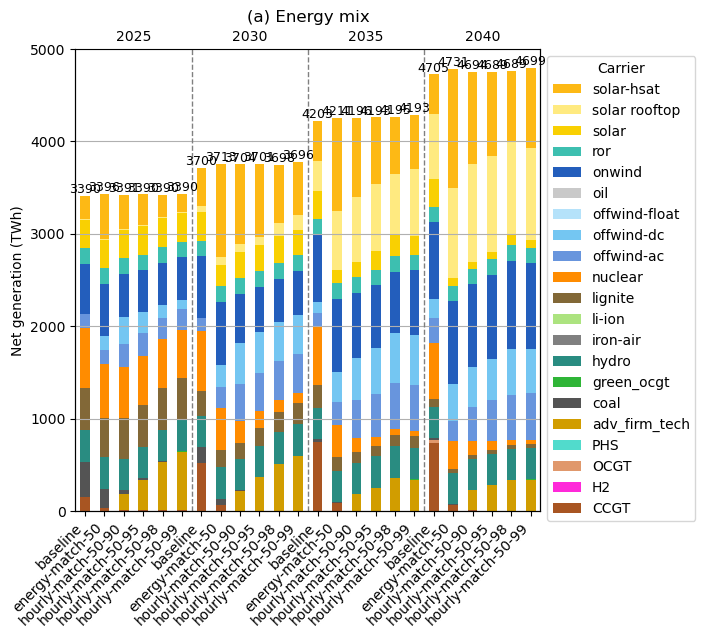

In [25]:
results = "Energy mix"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results


df, colors = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier"])
df["color"] = colors

df = df[
    df.index.get_level_values("bus_carrier").isin(["AC",
                                                   "low voltage",
                                                   ])
    & ~df.index.get_level_values("carrier").isin(["AC",
                                                  "DC",
                                                  "electricity",
                                                  "low voltage",
                                                  "electricity distribution grid",
                                                  "BEV charger",
                                                  "home battery charger",
                                                  "home battery discharger",
                                                  ])
]

df = df.groupby("carrier").apply(sum_except_color)
df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e6

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,5000])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (b) Energy mix - GO Market

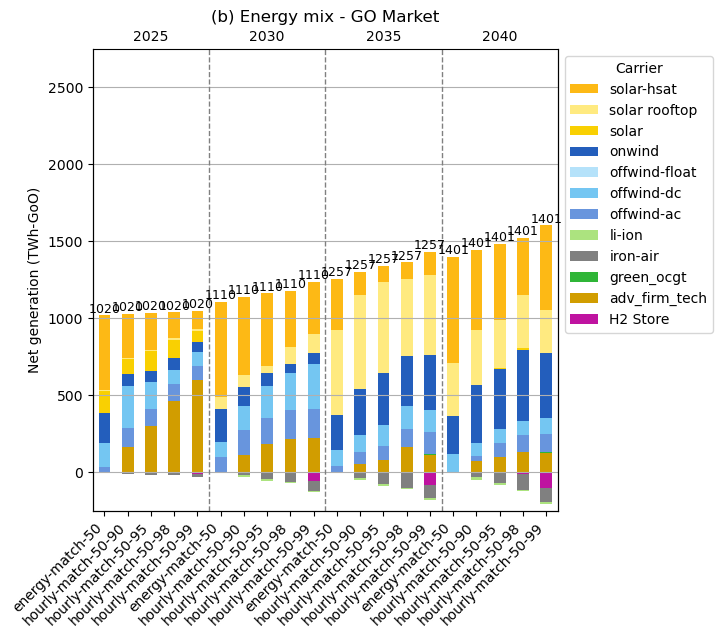

In [26]:
results = "Energy mix - GO Market"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results

df_GoO = df_networks[~df_networks.index.get_level_values("scenario").str.contains("baseline")]
df, colors = get_stats_all(df_GoO["GoO"], "energy_balance")
df["color"] = colors
df = df[df.index.get_level_values("carrier") != "GoO"].groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e6

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[-250,2750])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (c) Capacity mix

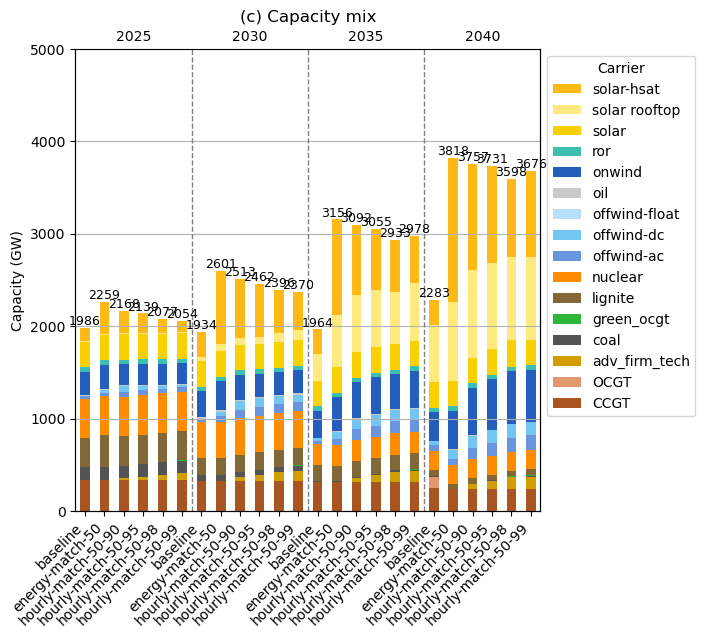

In [27]:
results = "Capacity mix"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier"])
df["color"] = colors

df = df[
    ~df.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
    & ~df.index.get_level_values("carrier").isin(["AC","DC","electricity distribution grid","low voltage"] + list(grouping_storage.keys()))
    & ~df.index.get_level_values("component").isin(["Store","StorageUnit"])
]

df = df.loc[~df.index.isin([("Generator","coal","coal"),("Generator","gas","gas")])]
df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e3

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,5000])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)
    
    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (d) Capacity mix - new technologies (proxy of GO Market)

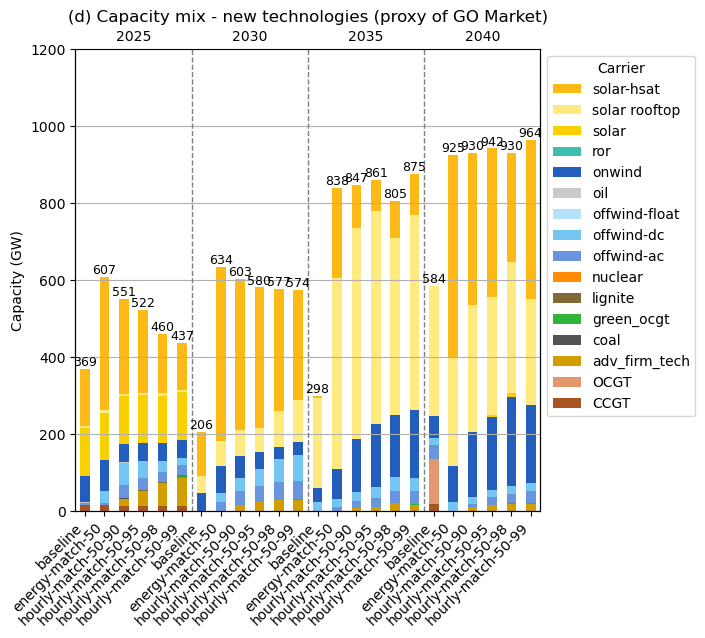

In [28]:
results = "Capacity mix - new technologies (proxy of GO Market)"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier","build_year"])

for c in df.columns:
    scenario_year = int(c[0])
    df.loc[df.index.get_level_values("build_year") != scenario_year,c] = 0

df["color"] = colors

df = df[
    ~df.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
    & ~df.index.get_level_values("carrier").isin(["AC","DC","electricity distribution grid","low voltage"] + list(grouping_storage.keys()))
    & ~df.index.get_level_values("component").isin(["Store","StorageUnit"])
]

df = df.loc[~df.index.isin([("Generator","coal","coal"),("Generator","gas","gas")])]
df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e3

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,1200])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (e) Storage in GO Market - Energy capacity (stores)

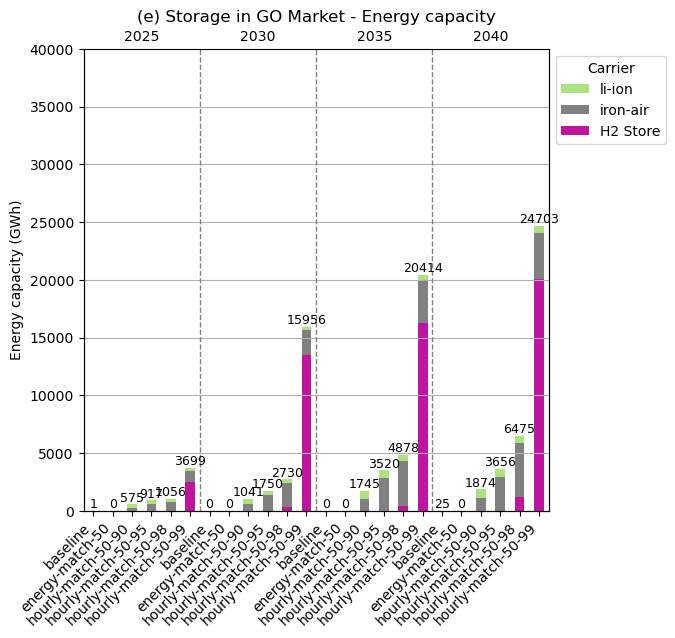

In [29]:
results = "Storage in GO Market - Energy capacity"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "optimal_capacity")
df["color"] = colors

df = df[
    df.index.get_level_values("component").isin(["Store"])
    & df.index.get_level_values("carrier").isin(list(grouping_storage.keys()))
    & ~df.index.get_level_values("carrier").isin(['EV battery','home battery'])
]

df = df.groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e3

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,40000])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (e) Storage in GO Market - Power capacity (links)

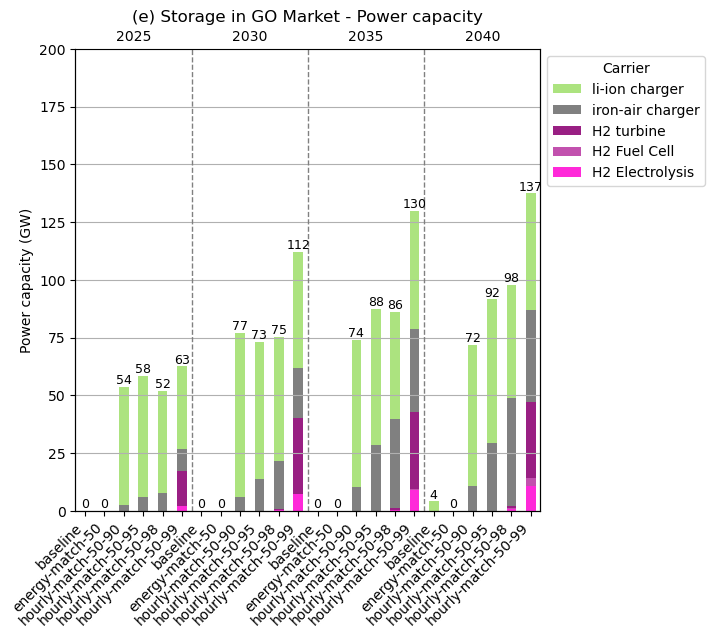

In [30]:
results = "Storage in GO Market - Power capacity"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "optimal_capacity")
df["color"] = colors

df = df[
    df.index.get_level_values("component").isin(["Link"])
    & df.index.get_level_values("carrier").isin(list(grouping_storage.keys()))
    & ~df.index.get_level_values("carrier").isin(['BEV charger','li-ion discharger','iron-air discharger','home battery charger','home battery discharger'])
]

df = df.groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e3

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,200])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)
    
    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (f) Total system cost

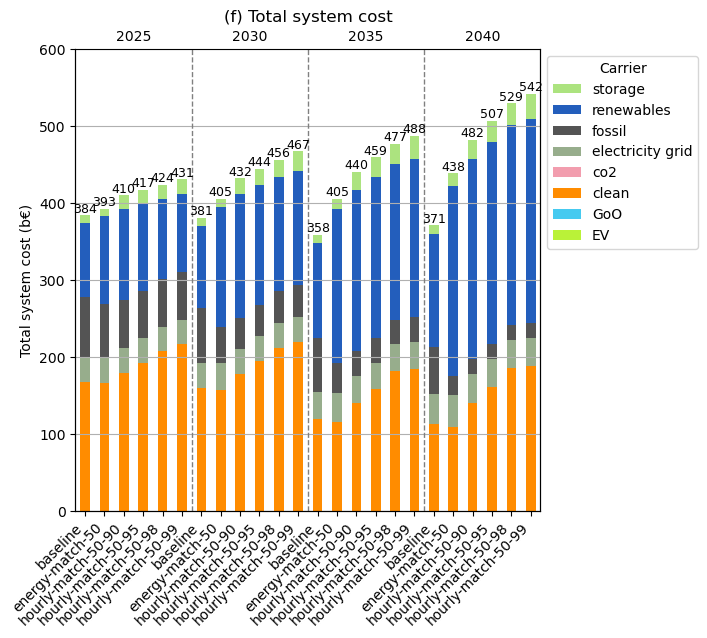

In [31]:
results = "Total system cost" # NOTE: This excludes GO Penalty
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, _ = get_stats_all(df_networks["network"], "system_cost")
df = df.rename(index=rename_map).groupby("carrier").sum()
df = df[df.index != "GO penalty"]
df = df / 1e9 # to Billion

colors = pd.Series([category_colors[i] for i in df.index], index=df.index)

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,600])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)
    
    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (g) Total system cost - new technologies (proxy of GO Market)

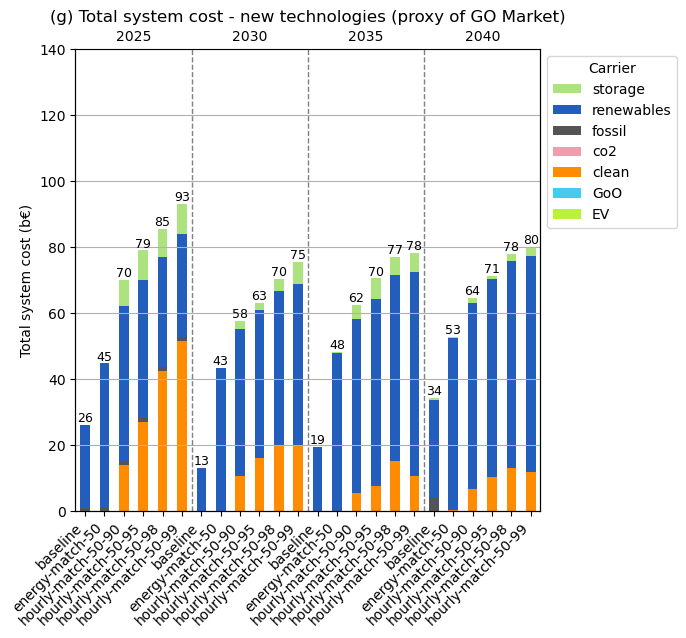

In [32]:
results = "Total system cost - new technologies (proxy of GO Market)"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, _ = get_stats_all(df_networks["network"], "system_cost", groupby=["carrier","build_year"])

for c in df.columns:
    scenario_year = int(c[0])
    df.loc[df.index.get_level_values("build_year") != scenario_year,c] = 0

df = df.rename(index=rename_map).groupby("carrier").sum()
df = df[df.index != "electricity grid"]
df = df / 1e9 # to Billion

colors = pd.Series([category_colors[i] for i in df.index], index=df.index)

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,140])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (h) GO Market revenue by technology

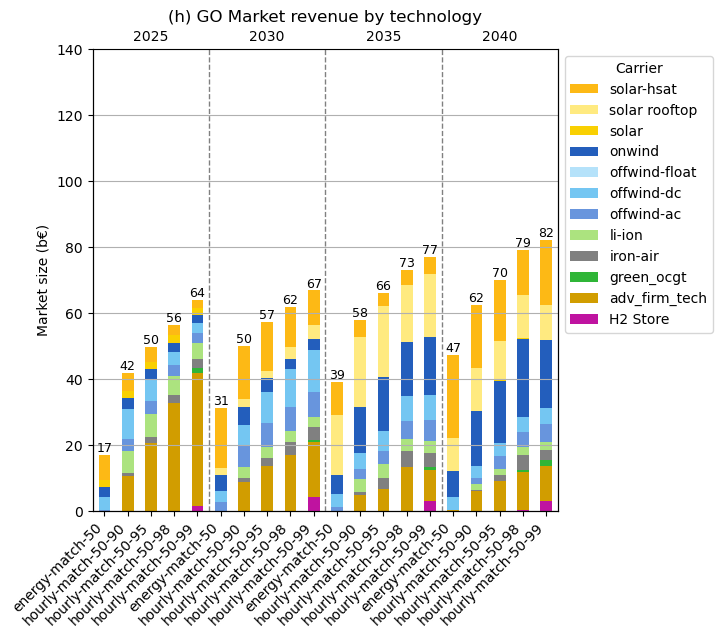

In [33]:
results = "GO Market revenue by technology"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results

df_GoO = df_networks[~df_networks.index.get_level_values("scenario").str.contains("baseline")]
df, colors = get_stats_all(df_GoO["GoO"], "revenue", groupby=["carrier"])
df["color"] = colors
df = df[df.index.get_level_values("carrier") != "GoO"].groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e9 # to Billion

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,140])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)
    
    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (i) Weighted average marginal price of GOs

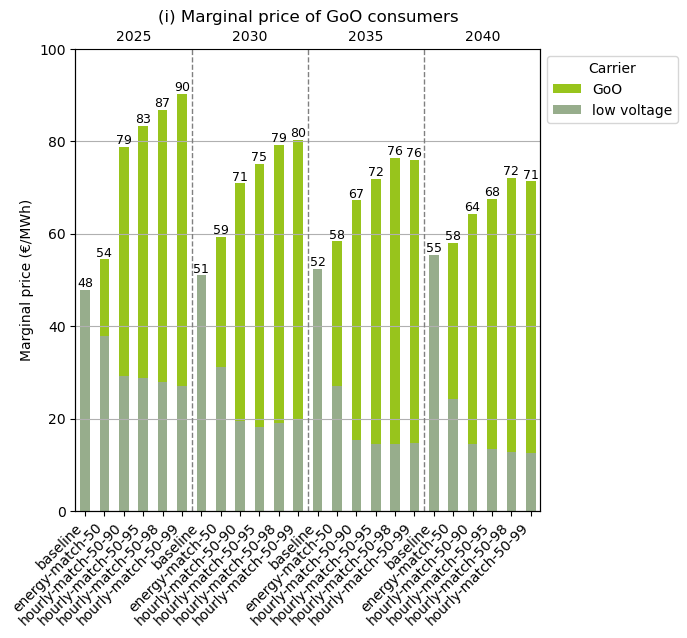

In [34]:
results = "Marginal price of GoO consumers"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, _ = get_stats_prices(df_networks["network"])

keywords = ["GO Demand", "low voltage"]
pattern = "|".join(keywords)

df = df[df.index.str.extract(f"({pattern})", expand=False).isin(keywords)]

df_w, _ = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus"], comps=["Load"])
df_w = df_w[df_w.index.get_level_values("bus").str.extract(f"({pattern})", expand=False).isin(keywords)]
df_w = df_w.groupby("bus").sum()

denominator = (
    df_w.groupby(df_w.index.map(n.buses.carrier))
        .transform("sum")
        .reindex(df.index)   # ensures alignment
)

df_weighted = df.mul(df_w).div(denominator)
df_weighted = df_weighted.groupby(df_weighted.index.map(n.buses.carrier)).sum()
df_weighted = df_weighted.loc[["low voltage","GoO"]]

colors = pd.Series(df_weighted.index.map(n.carriers.color), index=df_weighted.index)
# TODO: Set the y limit to 150
ax = plot_bar(df_weighted, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,100])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df_weighted.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

### (j) CO2 emissions

In [40]:
results = "CO2 emissions"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier"])
df["color"] = colors

df = df[
    df.index.get_level_values("bus_carrier").isin(["co2"])
    & df.index.get_level_values("component").isin(["Link"])
]
df = df.groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e6 # to MtC02

ax = plot_bar(df, colors, ylabel=y_label, title=title_fig, figsize=figsize, ylim=[0,1000])
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

KeyboardInterrupt: 

### (k) CFE curtailment

/tmp/ipykernel_217031/266563135.py:252: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_217031/3336217079.py:70: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/tmp/ipykernel_217031/3336217079.py:70: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



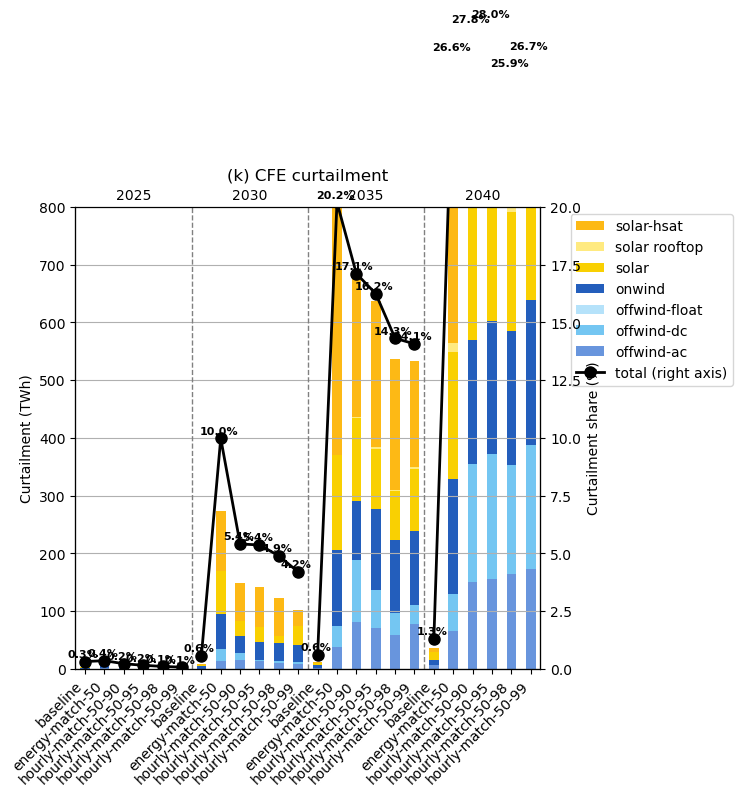

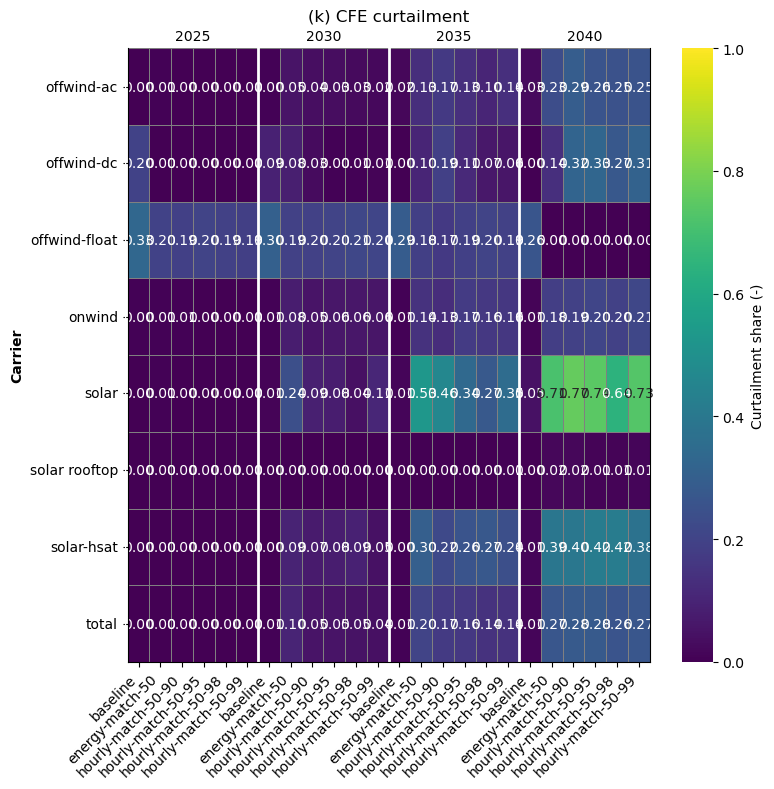

In [36]:
results = "CFE curtailment"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results
df, colors = get_stats_all(df_networks["network"], "curtailment", groupby=["carrier","bus_carrier"])
df["color"] = colors

df = df[
    df.index.get_level_values("bus_carrier").isin(["AC",
                                                   "low voltage",
                                                   ])
    & df.index.get_level_values("carrier").isin(vres_carriers)
]

df = df.groupby("carrier").apply(sum_except_color)
df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e6

# derive total curtailment and curtailment shares
df_curt = df.copy()
df_curt.loc["total"] = df_curt.sum(axis=0)

df_gen, colors_gen = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier"])

df_gen = df_gen[
    df_gen.index.get_level_values("bus_carrier").isin(["AC",
                                                   "low voltage",
                                                   ])
    & df_gen.index.get_level_values("carrier").isin(df_curt.index)
]

df_gen = df_gen.groupby("carrier").sum()
df_gen = df_gen / 1e6
df_gen.loc["total"] = df_gen.sum(axis=0)

df_curt_share = df_curt / (df_gen + df_curt)

# Use new function with share line
ax, ax_share = plot_bar_with_share(df, colors, df_curt_share, 
                                     ylabel=y_label, 
                                     ylabel_share="Curtailment share (%)",
                                     title=title_fig,
                                     figsize=figsize,
                                     ylim=[0,800],
                                     ylim_share=[0,20],
                                  )
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df_curt.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)


    df_csv = df_curt_share.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], ["Curtailment share (-)"], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

    colors.index = pd.MultiIndex.from_product([[title_fig], colors.index], names=['Results', 'carrier'])
    colors_list.append(colors)

#display(round(df_curt_share.T,2))

cmap_style = 'viridis'
#cmap_style = 'RdYlGn'
cmap = plt.cm.get_cmap(cmap_style)
norm = mcolors.Normalize(vmin=0, vmax=1)
#display(df_curt_share.T.style.background_gradient(cmap=cmap, vmin=0, vmax=1).format("{:.2f}"))

ax = plot_heatmap(df_curt_share, title_fig, cmap_style, legend_title = "Curtailment share (-)", figsize=figsize_heatmap)
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig} table.png", dpi=300, bbox_inches="tight")

### (l) CFE utilization

/tmp/ipykernel_273737/3705890064.py:27: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



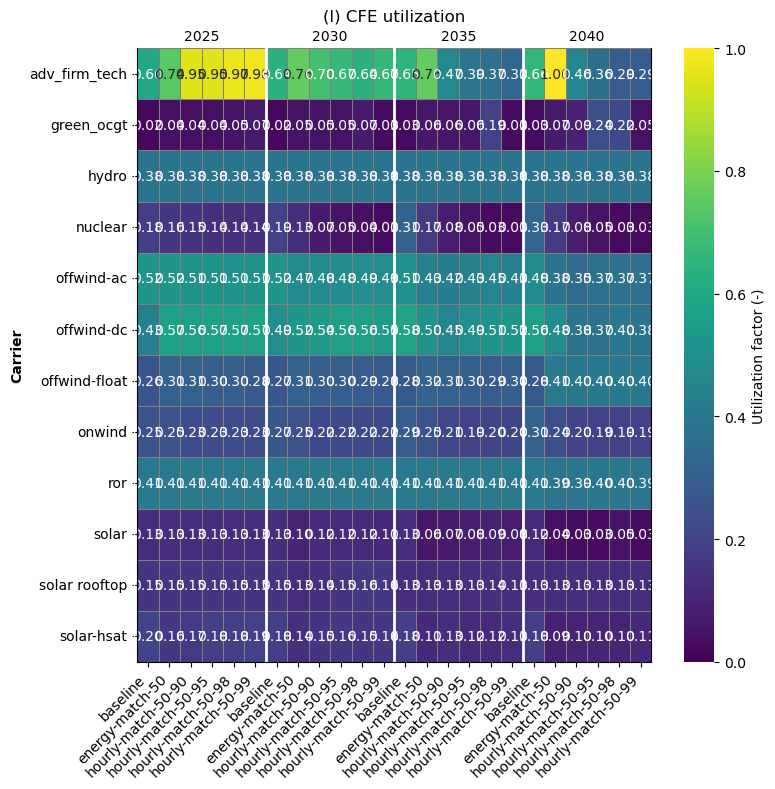

KeyboardInterrupt: 

In [4]:
results = "CFE utilization"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results

# Net yearly generation
df_gen, _ = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier"])

df_gen = df_gen[
    df_gen.index.get_level_values("bus_carrier").isin(["AC",
                                                   "low voltage",
                                                   ])
    & df_gen.index.get_level_values("carrier").isin(clean_carriers)
].groupby("carrier").sum()

# Nominal yearly generation
df_cap, _ = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier"])

df_cap = df_cap[
    ~df_cap.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
    & df_cap.index.get_level_values("carrier").isin(clean_carriers)
].groupby("carrier").sum()

# Calculate utilization rate
cmap_style = 'viridis'
#cmap_style = 'RdYlGn'
cmap = plt.cm.get_cmap(cmap_style)
norm = mcolors.Normalize(vmin=0, vmax=1)
df_use = round(df_gen / (df_cap * 8760), 2)
#display(df_use.T.style.background_gradient(cmap=cmap, vmin=0, vmax=1).format("{:.2f}"))

ax = plot_heatmap(df_use, title_fig, cmap_style, legend_title = y_label, figsize=figsize_heatmap)
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df_use.copy()
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

### (m) CO2 abatement cost

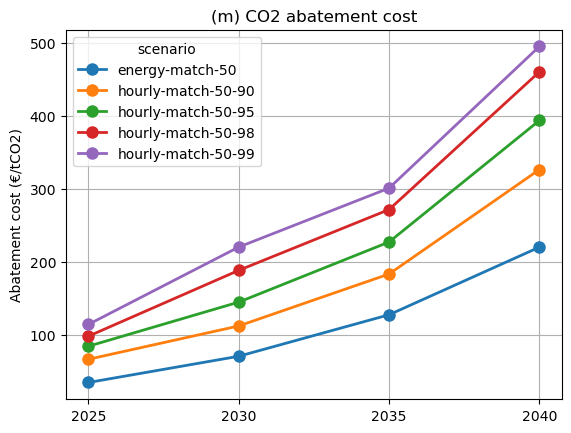

In [12]:
results = "CO2 abatement cost"
letter = plot_formats[results]['letter']
y_label = plot_formats[results]['y_label']
title_fig = letter + " " + results

# Derive total system cost
df, _ = get_stats_all(df_networks["network"], "system_cost")
df = df.rename(index=rename_map).groupby("carrier").sum()
df = df[df.index != "GO penalty"]
df = df / 1e9 # to Billion
df_cost = df.copy()
df_cost.loc["total"] = df_cost.sum(axis=0)

# Derive CO2 emissions
df, _ = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier"])
df = df[
    df.index.get_level_values("bus_carrier").isin(["co2"])
    & df.index.get_level_values("component").isin(["Link"])
]
df = df.groupby("carrier").sum()
df = df / 1e6 # to MtC02
df_co2 = df.copy()
df_co2.loc["total"] = df_co2.sum(axis=0)

ax, df_ac = plot_abatement_cost(df_cost, df_co2, title=title_fig, y_label=y_label)
if save_fig:
    os.makedirs(fig_path, exist_ok=True)
    ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    df_csv = df_ac.copy().unstack("scenario").to_frame().T
    df_csv["carrier"] = "abatement cost"
    df_csv =df_csv.set_index("carrier")
    df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
    dfs_list.append(df_csv)

### Save .csv files

In [38]:
csv_path_results = os.path.join(fig_path, "results.csv")
os.makedirs(fig_path, exist_ok=True)
dfs_csv = pd.concat(dfs_list, axis = 0)
dfs_csv.to_csv(csv_path_results)
print(f"Results saved to {csv_path_results}")

csv_path_colors = os.path.join(fig_path_colors, "colors.csv")
os.makedirs(fig_path_colors, exist_ok=True)
colors_csv = pd.concat(colors_list, axis = 0)
colors_csv.to_csv(csv_path_colors)
print(f"Colors saved to {csv_path_colors}")

Results saved to figures/time_comparison/system-50/results.csv
Colors saved to figures/time_comparison/colors.csv


# 3 - GO Market impacts: single countries

-------------------------------------Analyzing Germany


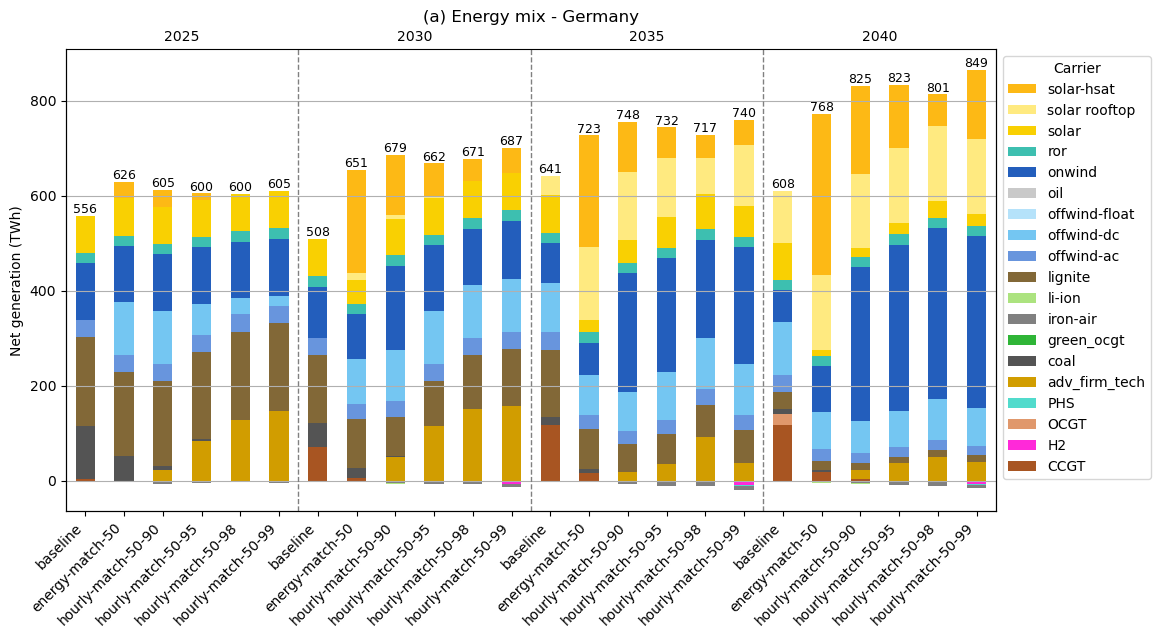

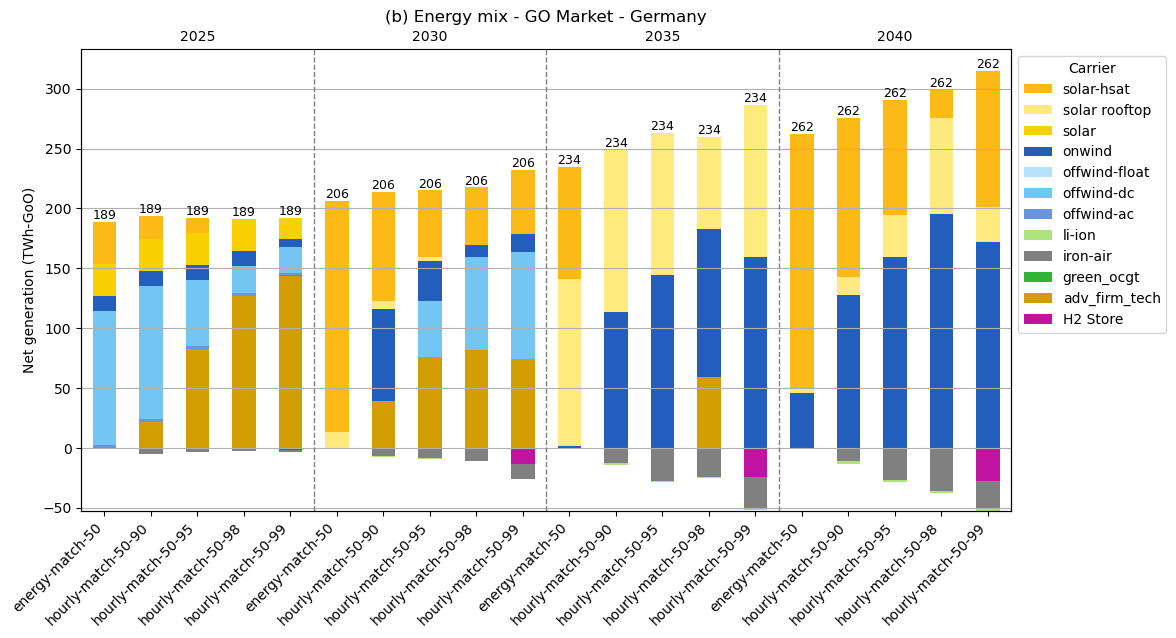

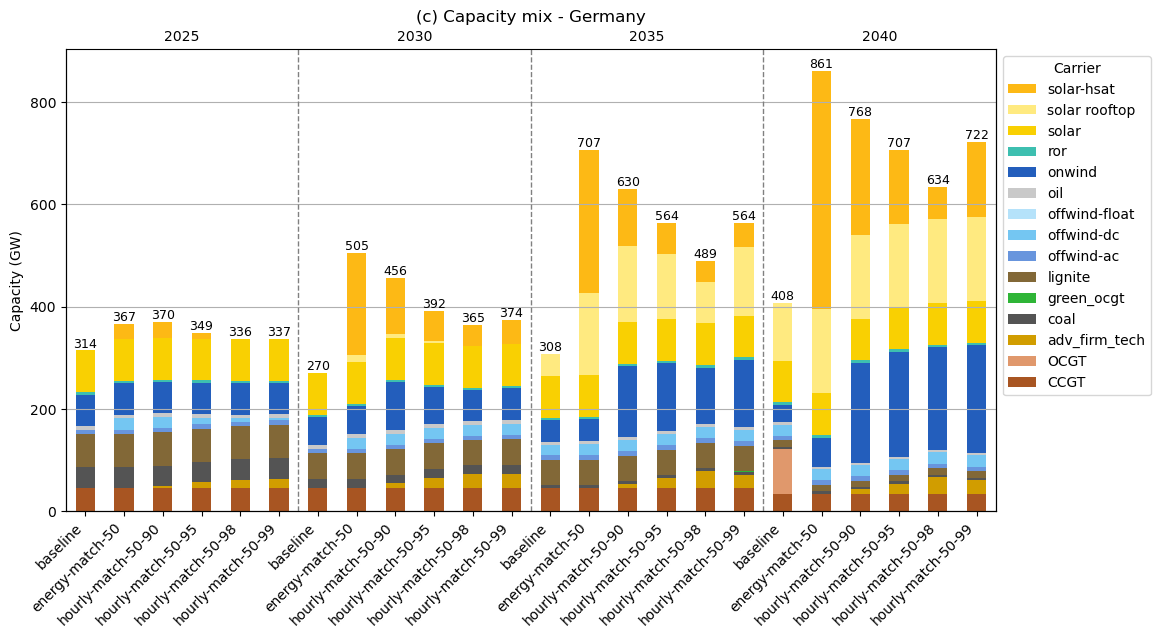

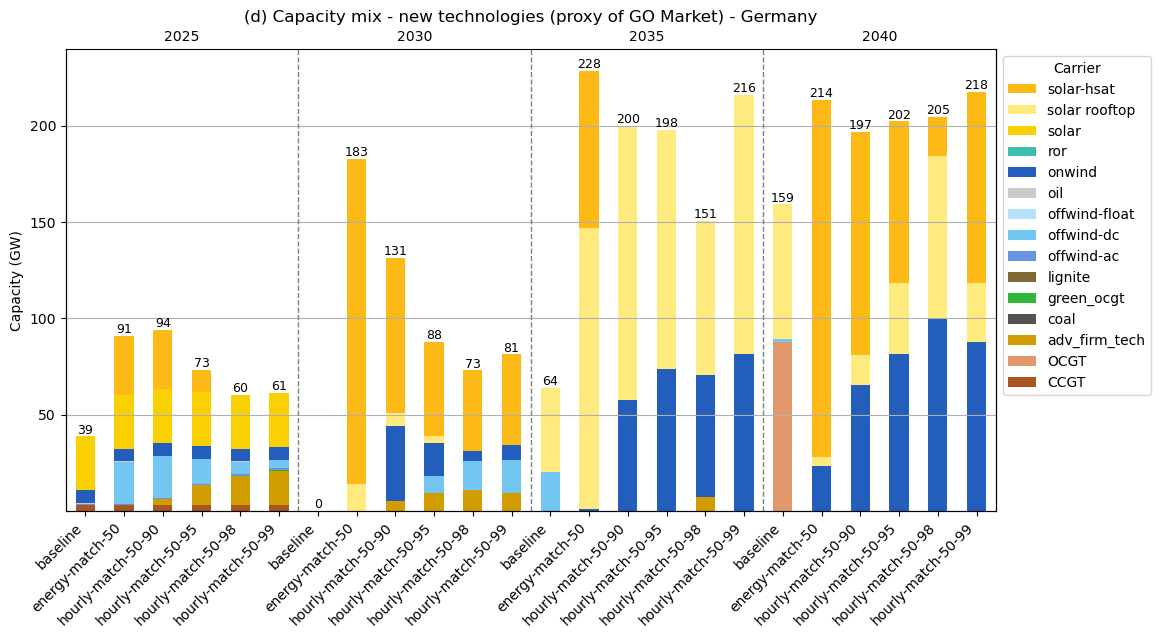

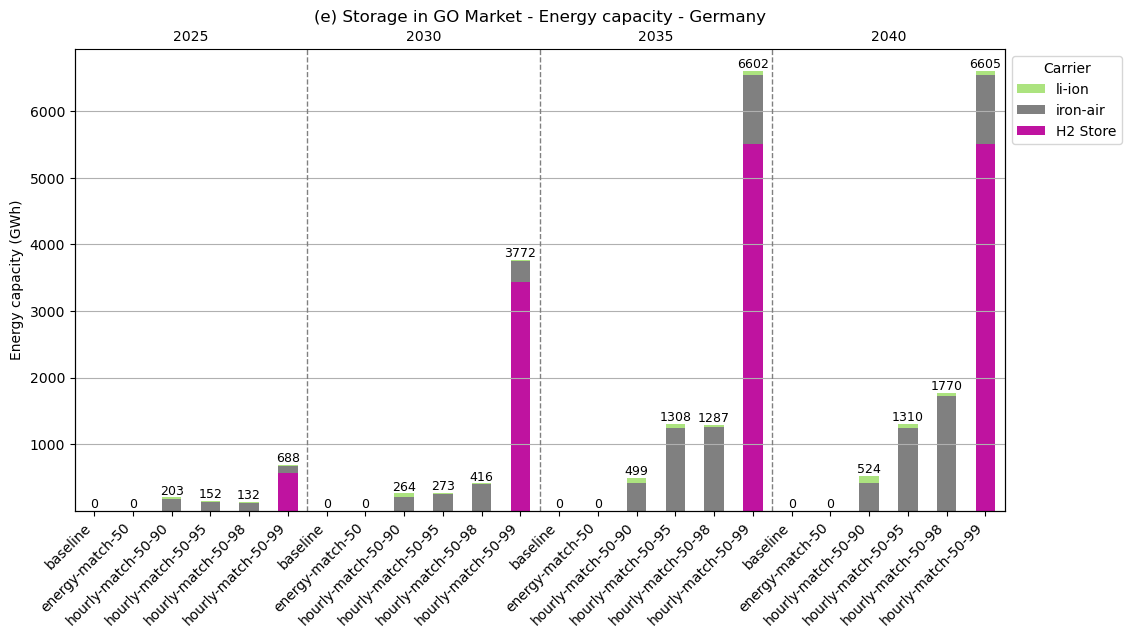

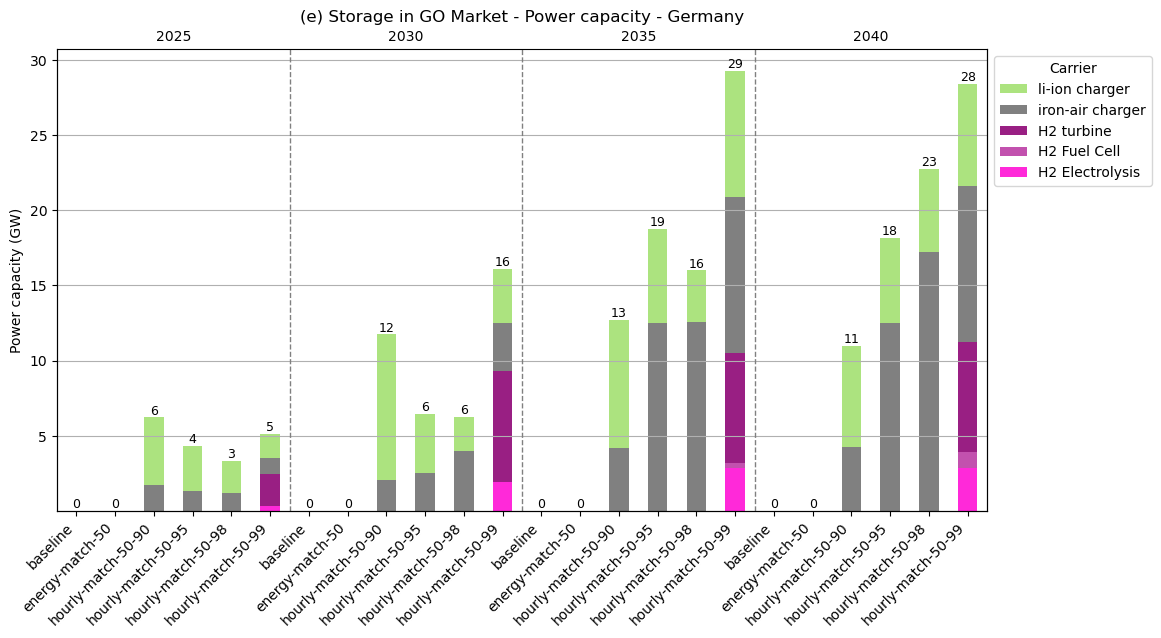

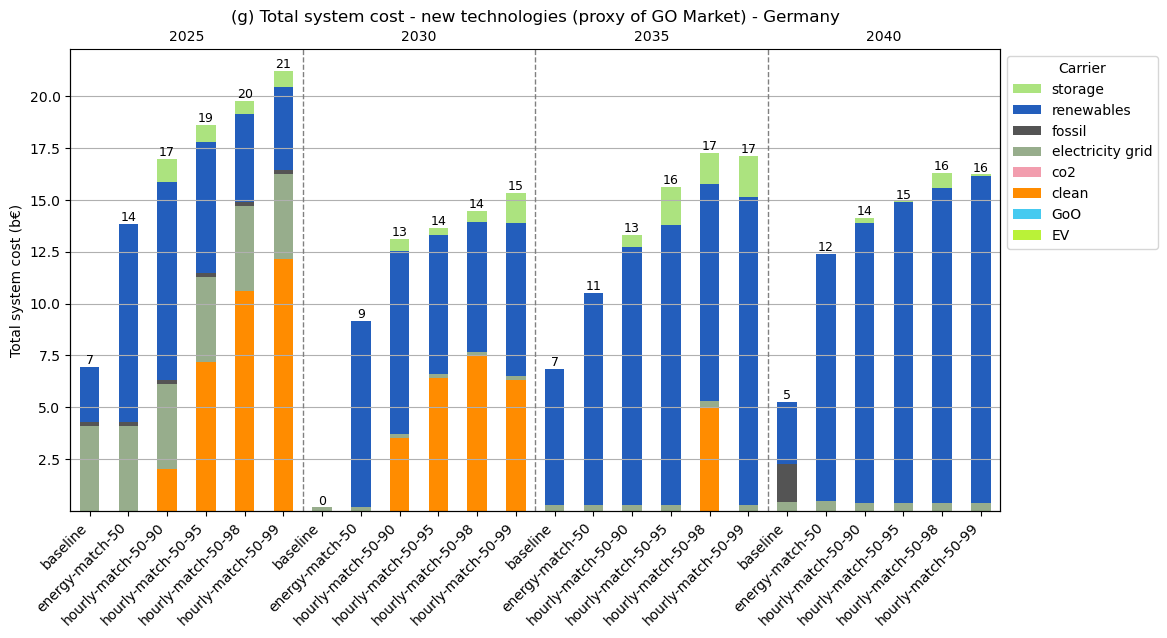

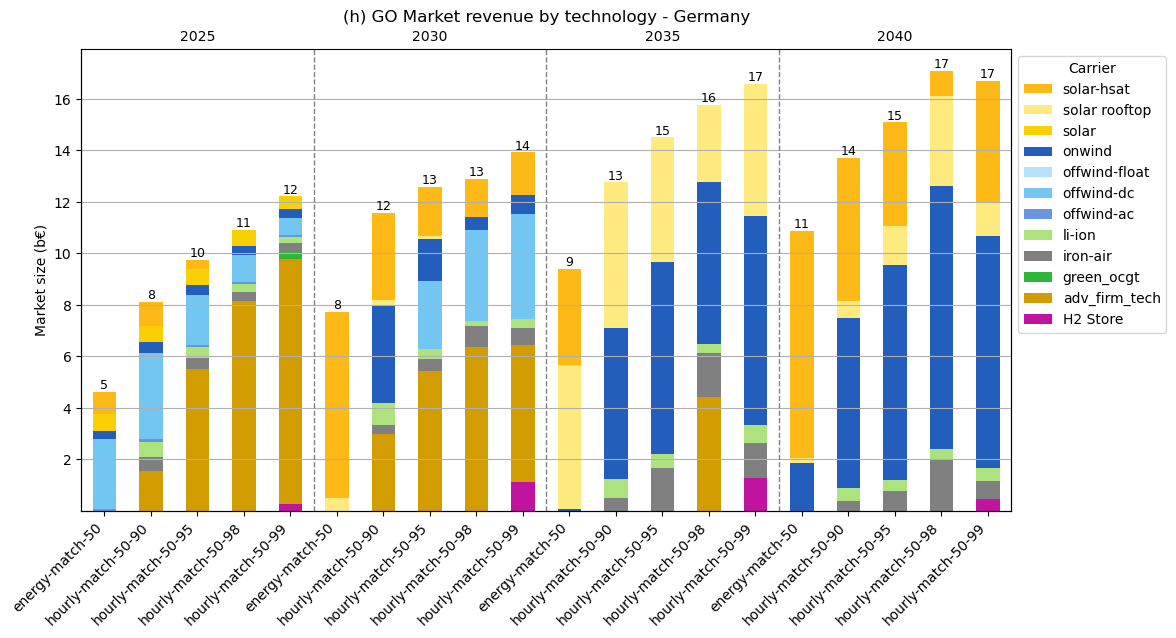

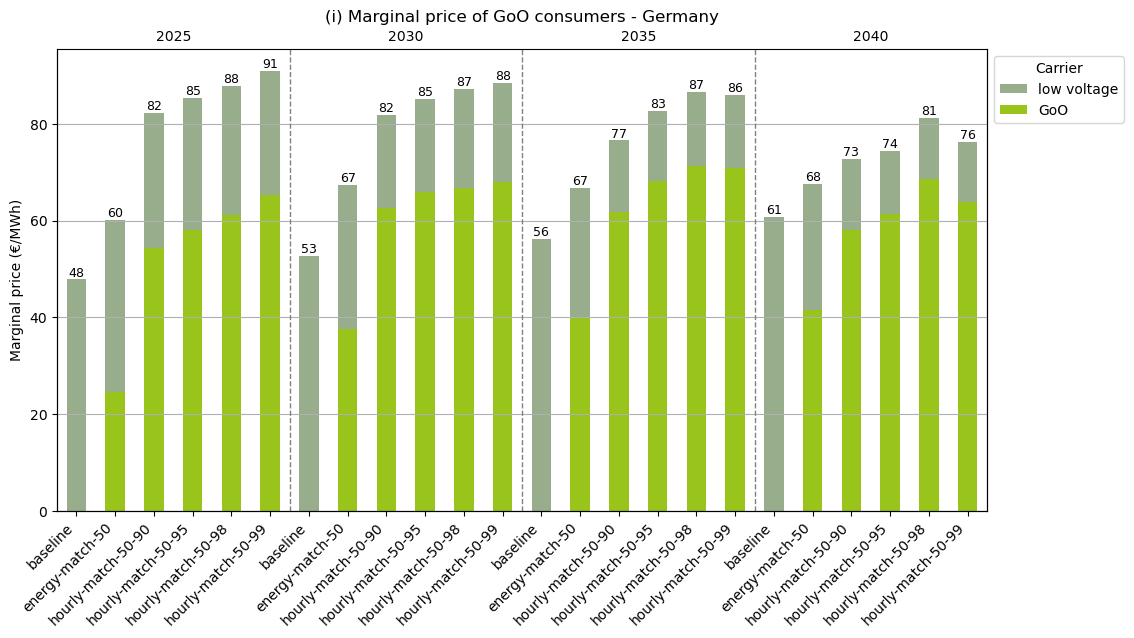

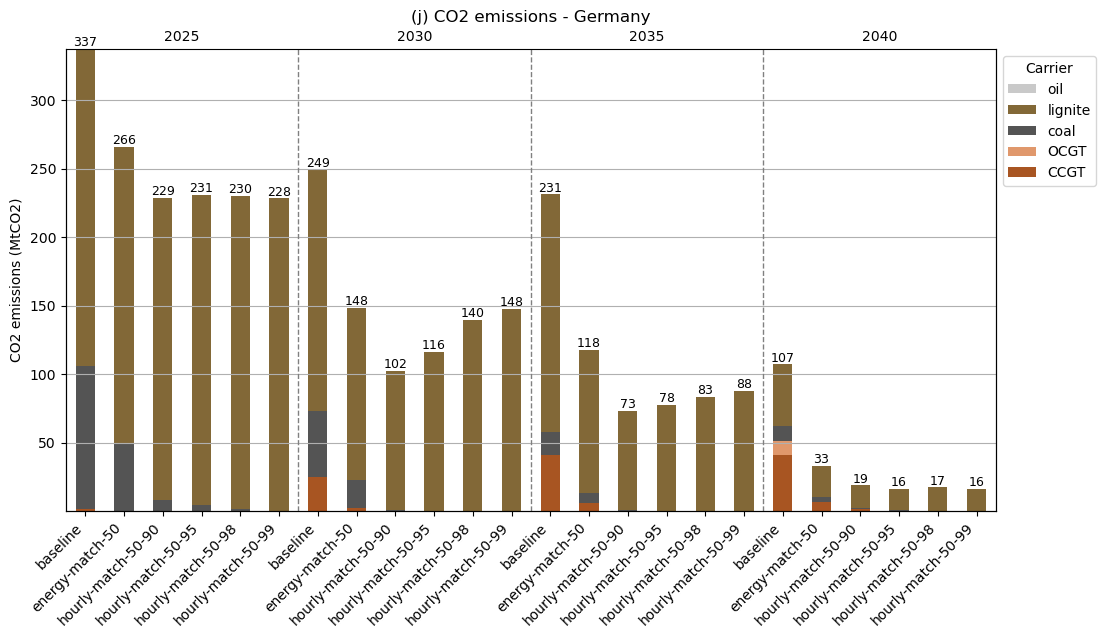

/tmp/ipykernel_217031/266563135.py:252: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



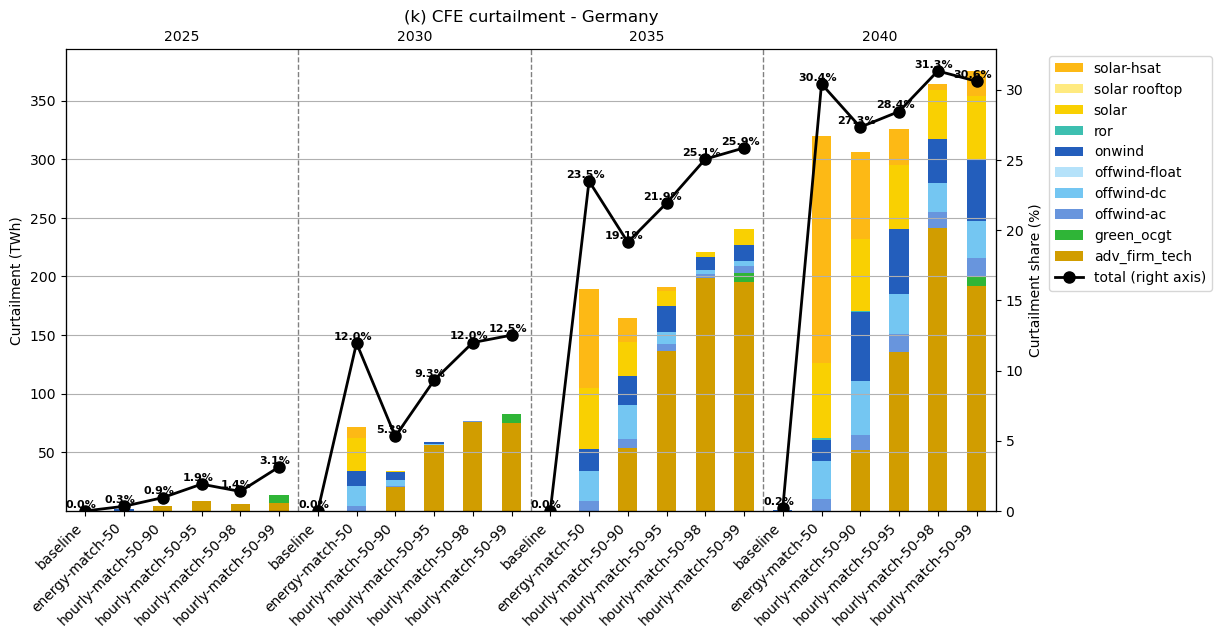

/tmp/ipykernel_217031/436801255.py:418: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



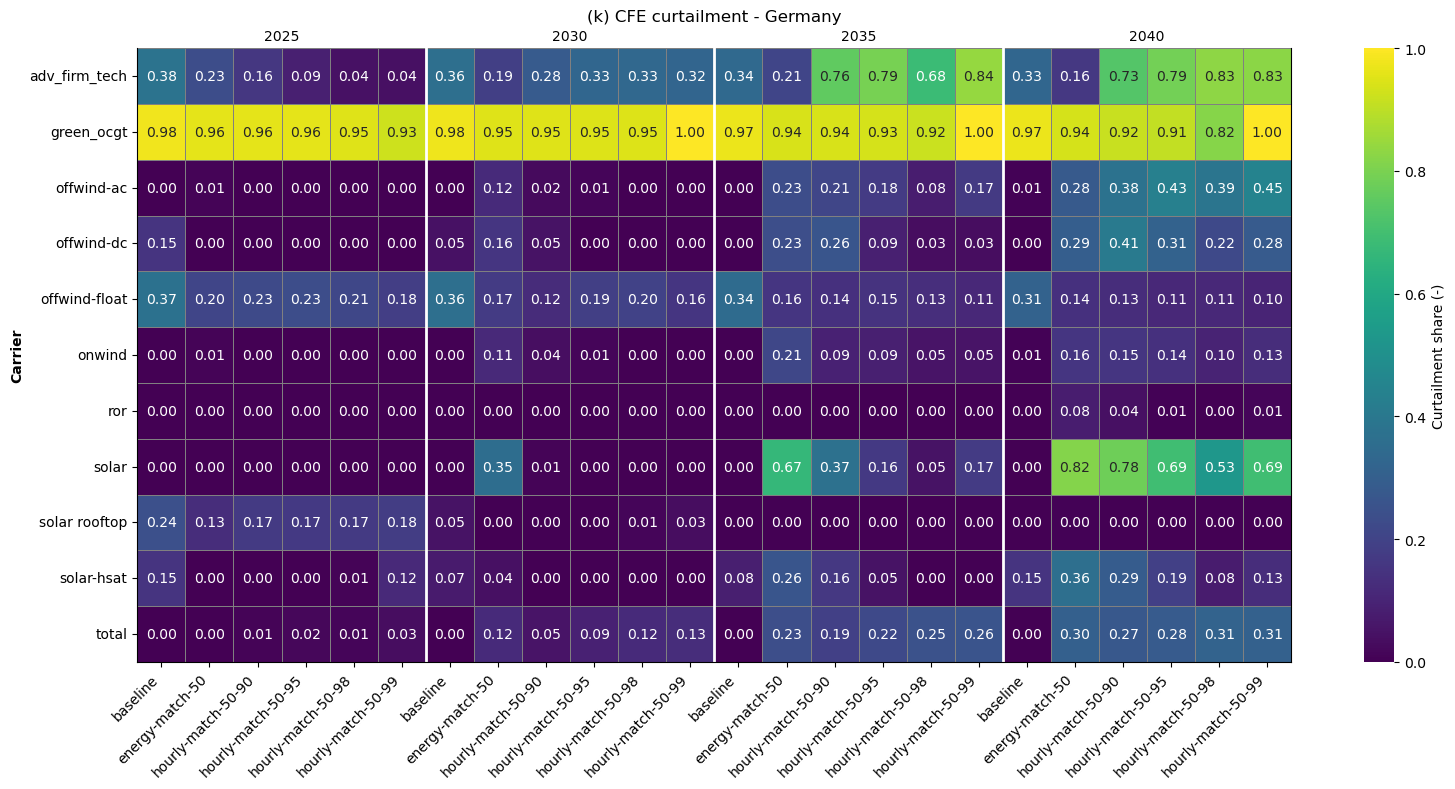

/tmp/ipykernel_217031/436801255.py:466: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



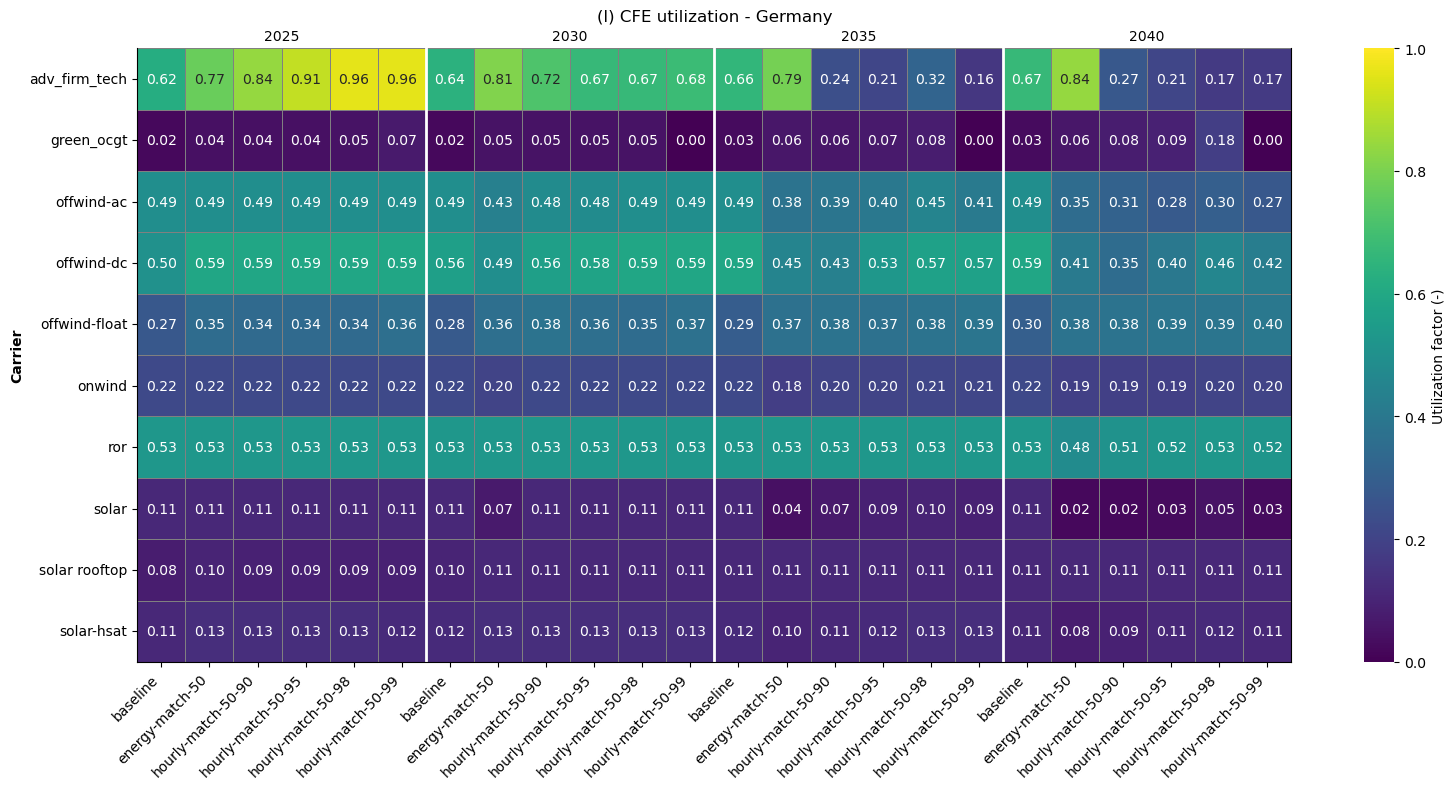

Results saved to figures/time_comparison/country-50/Germany/results-Germany.csv
-------------------------------------Analyzing Italy


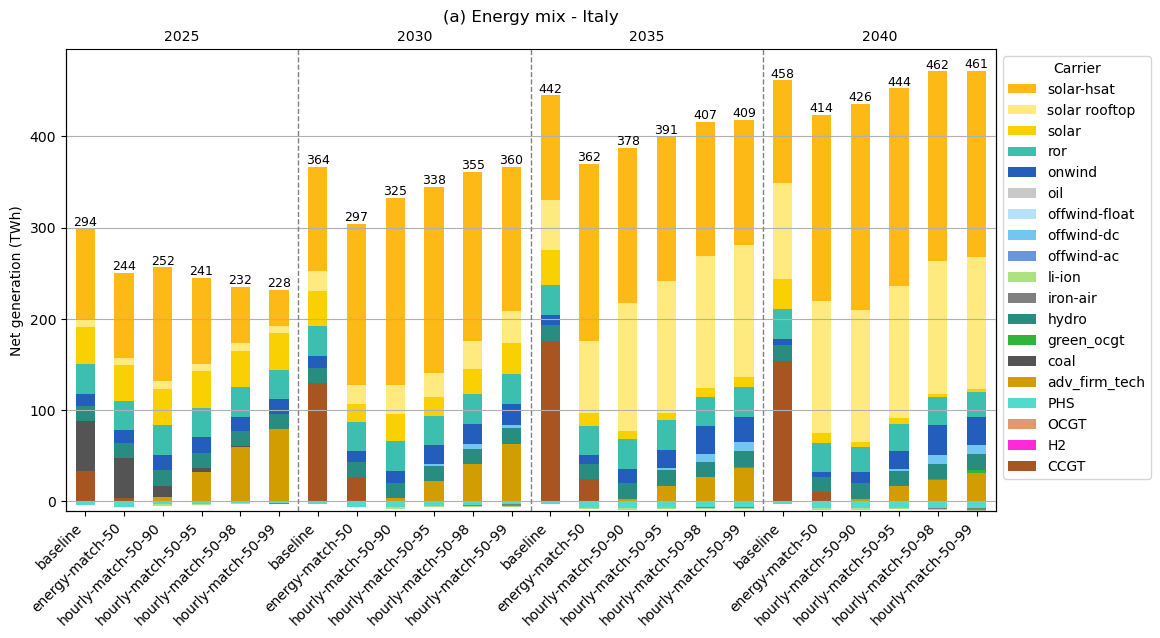

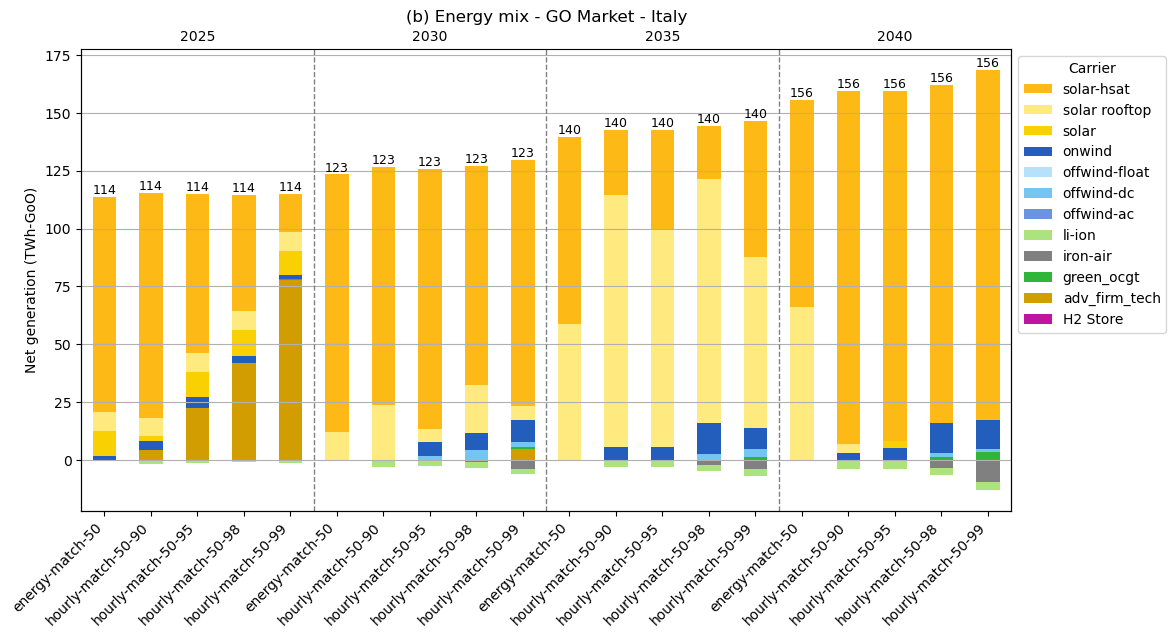

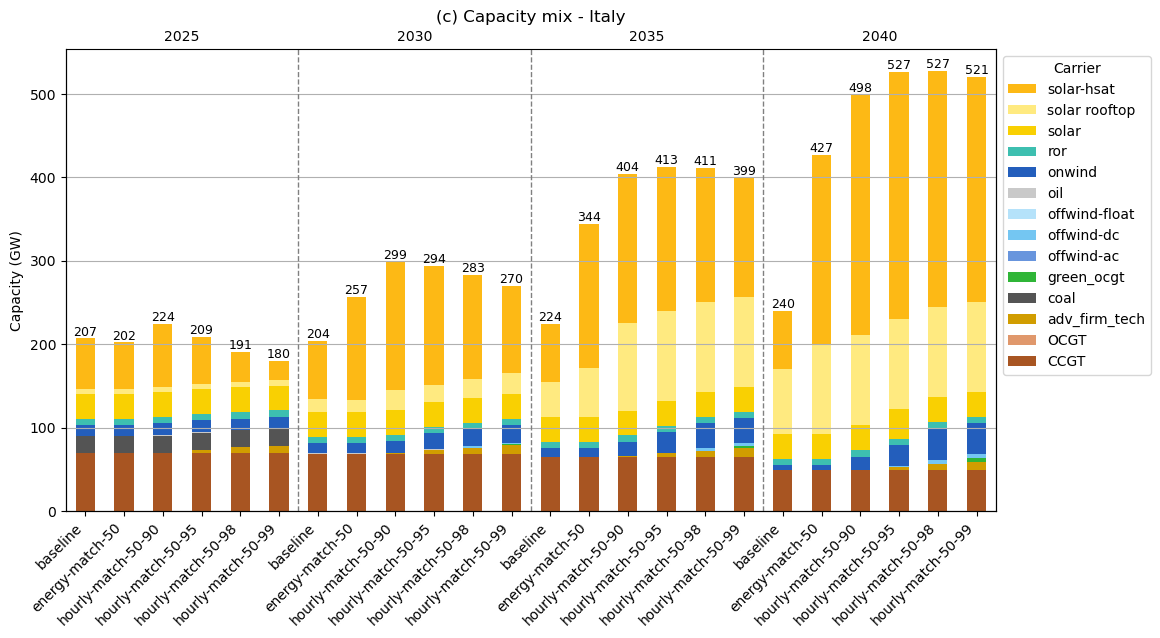

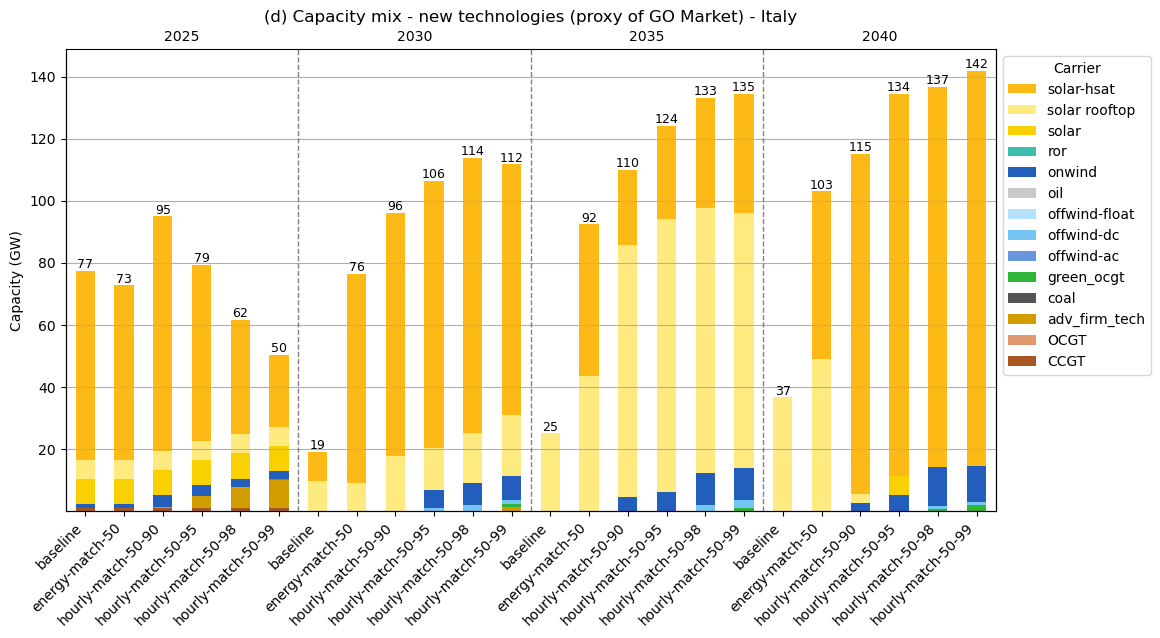

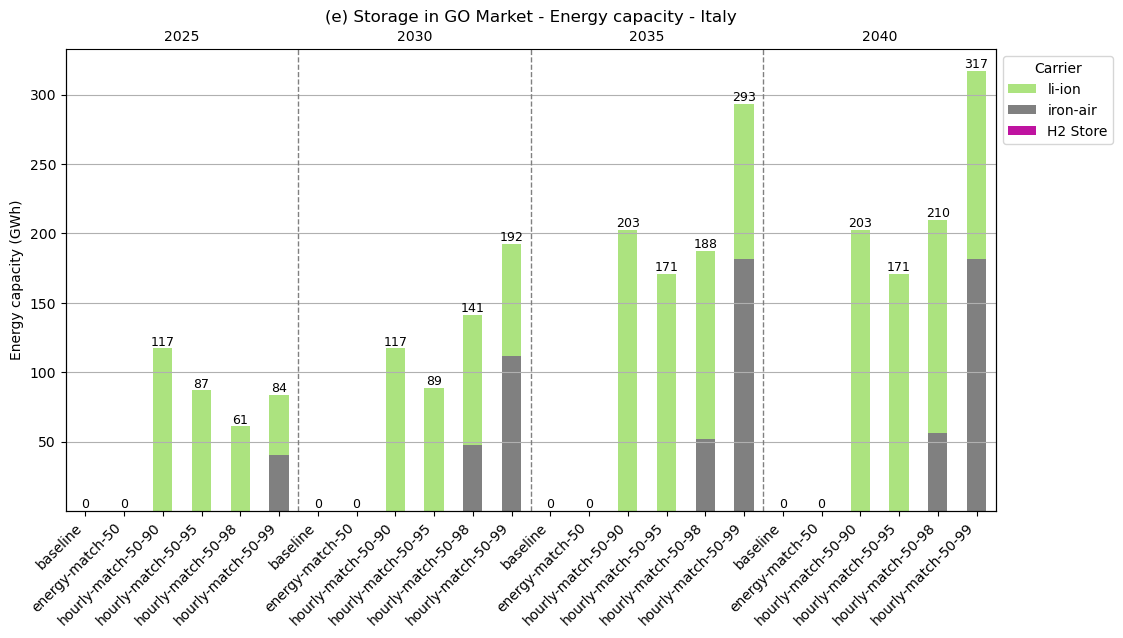

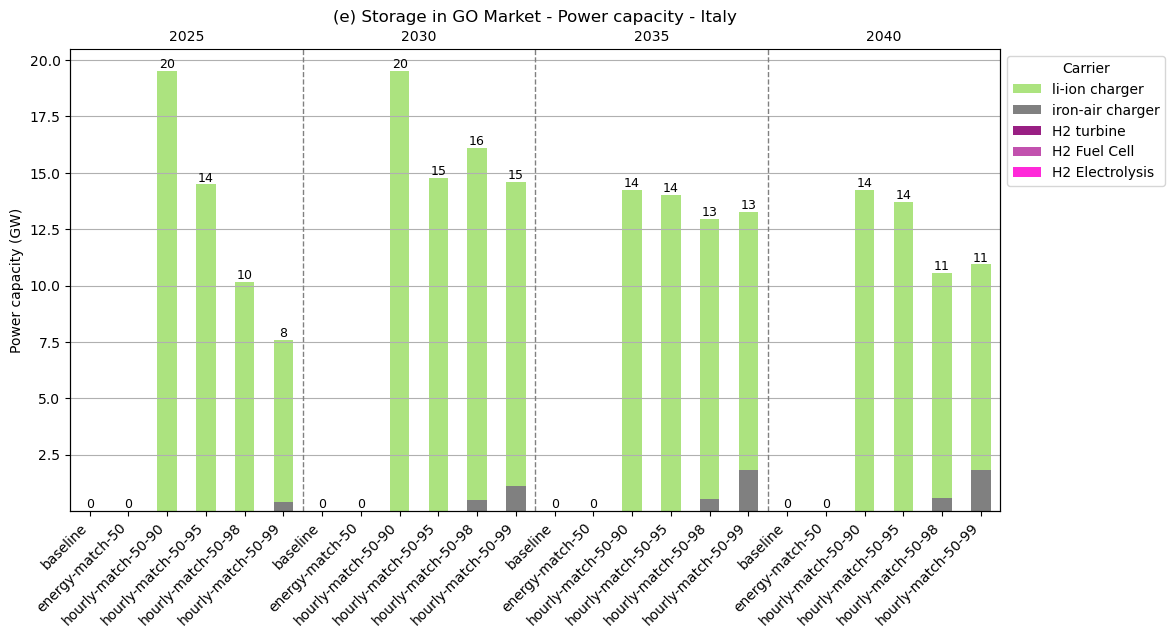

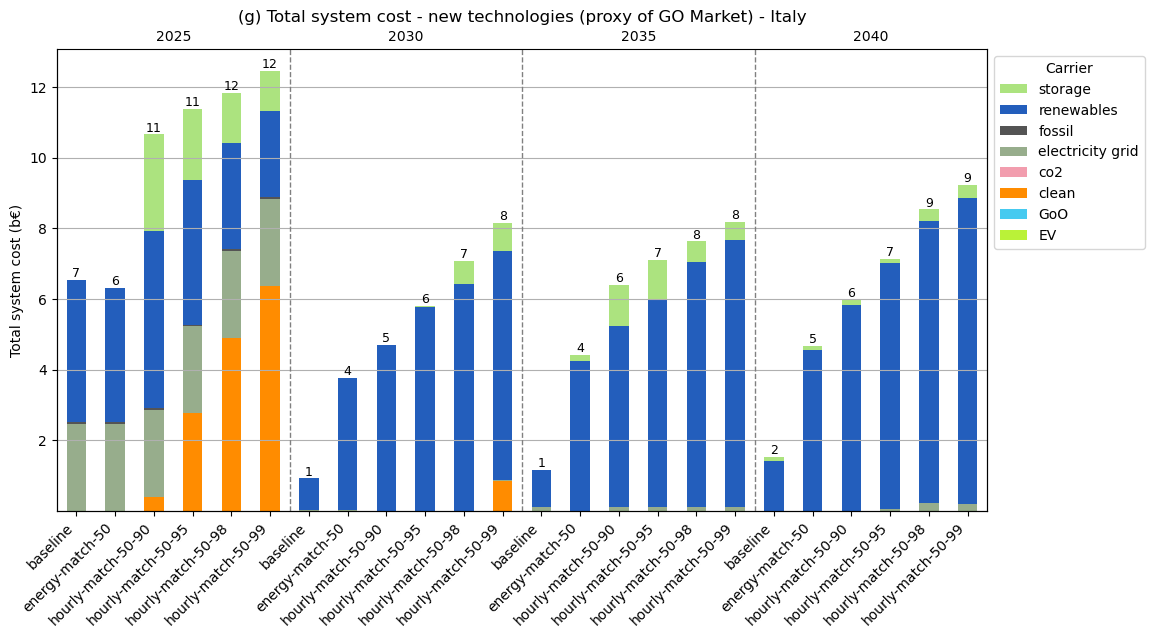

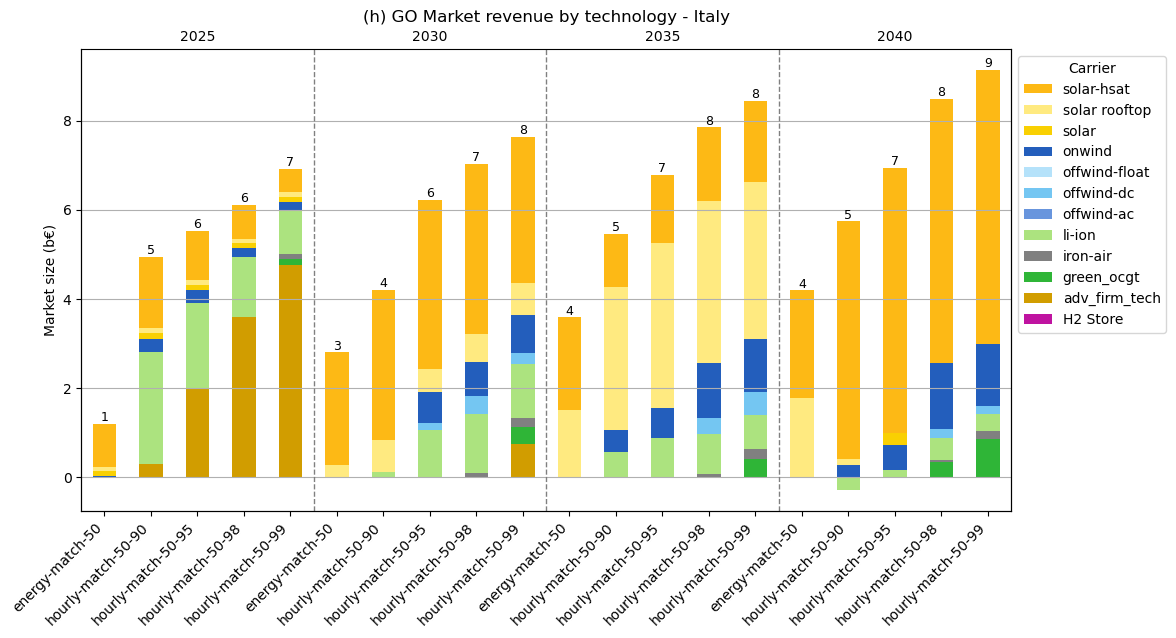

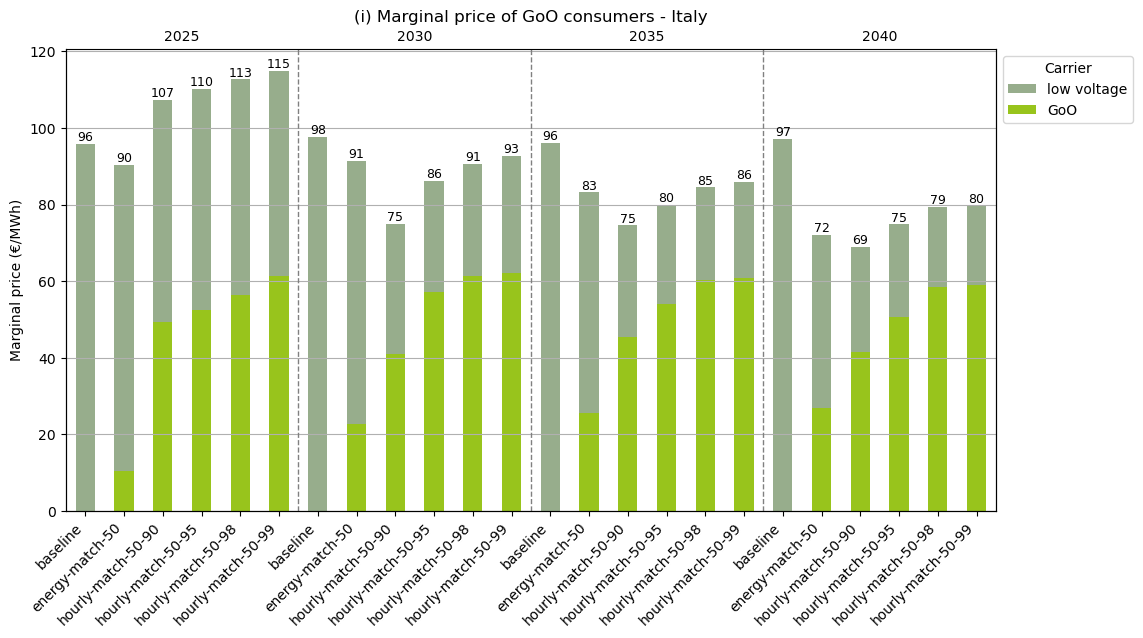

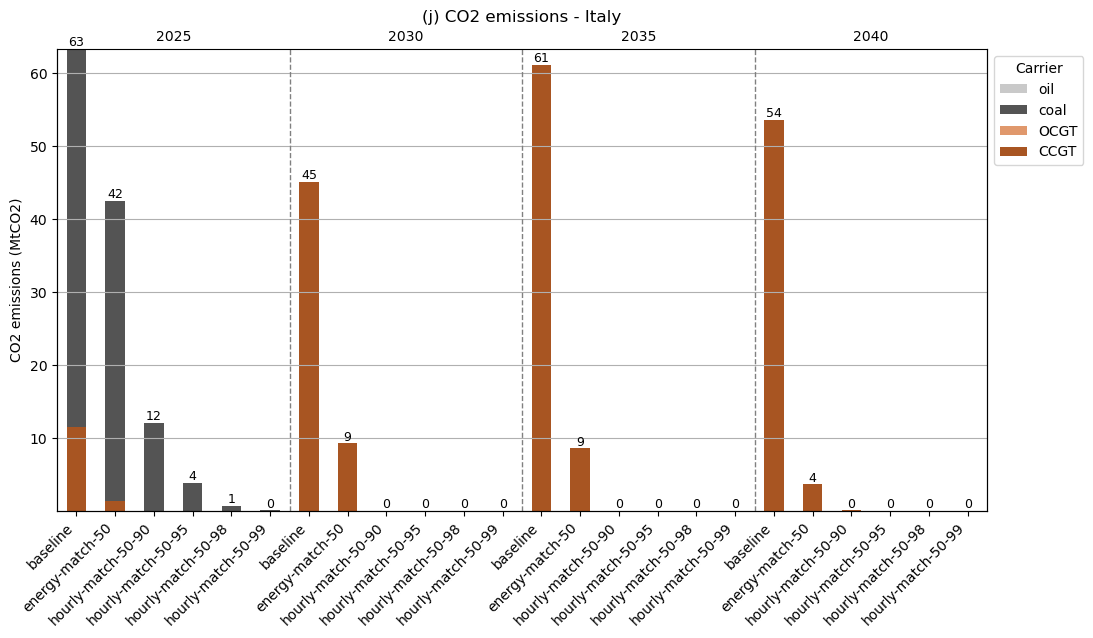

/tmp/ipykernel_217031/266563135.py:252: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



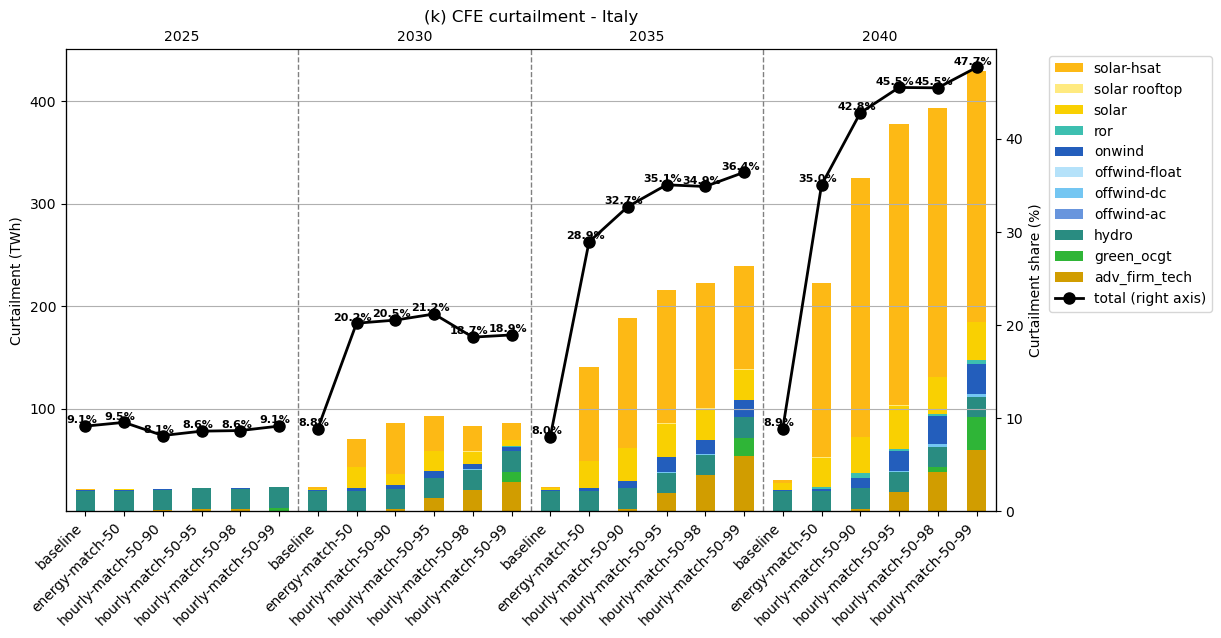

/tmp/ipykernel_217031/436801255.py:418: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



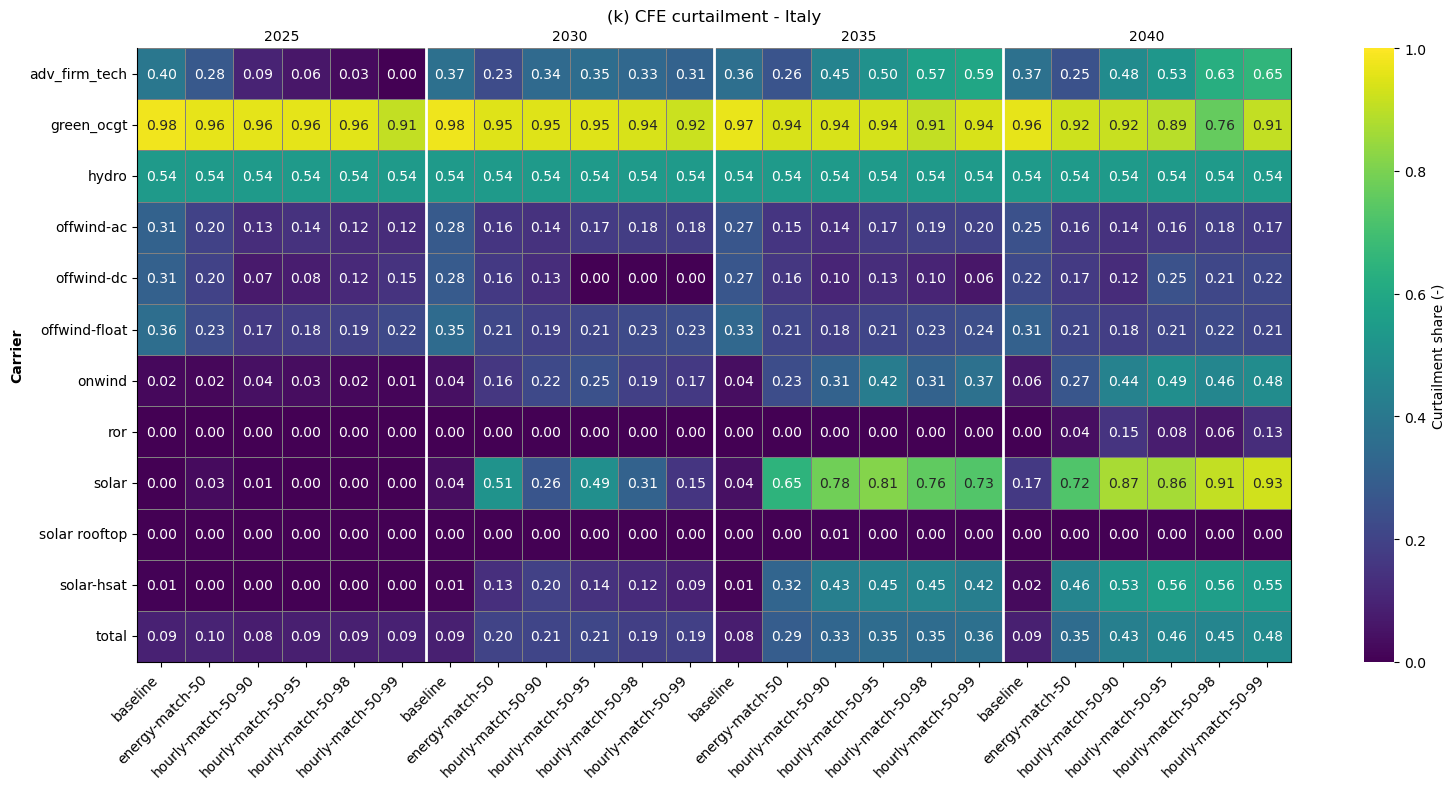

/tmp/ipykernel_217031/436801255.py:466: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



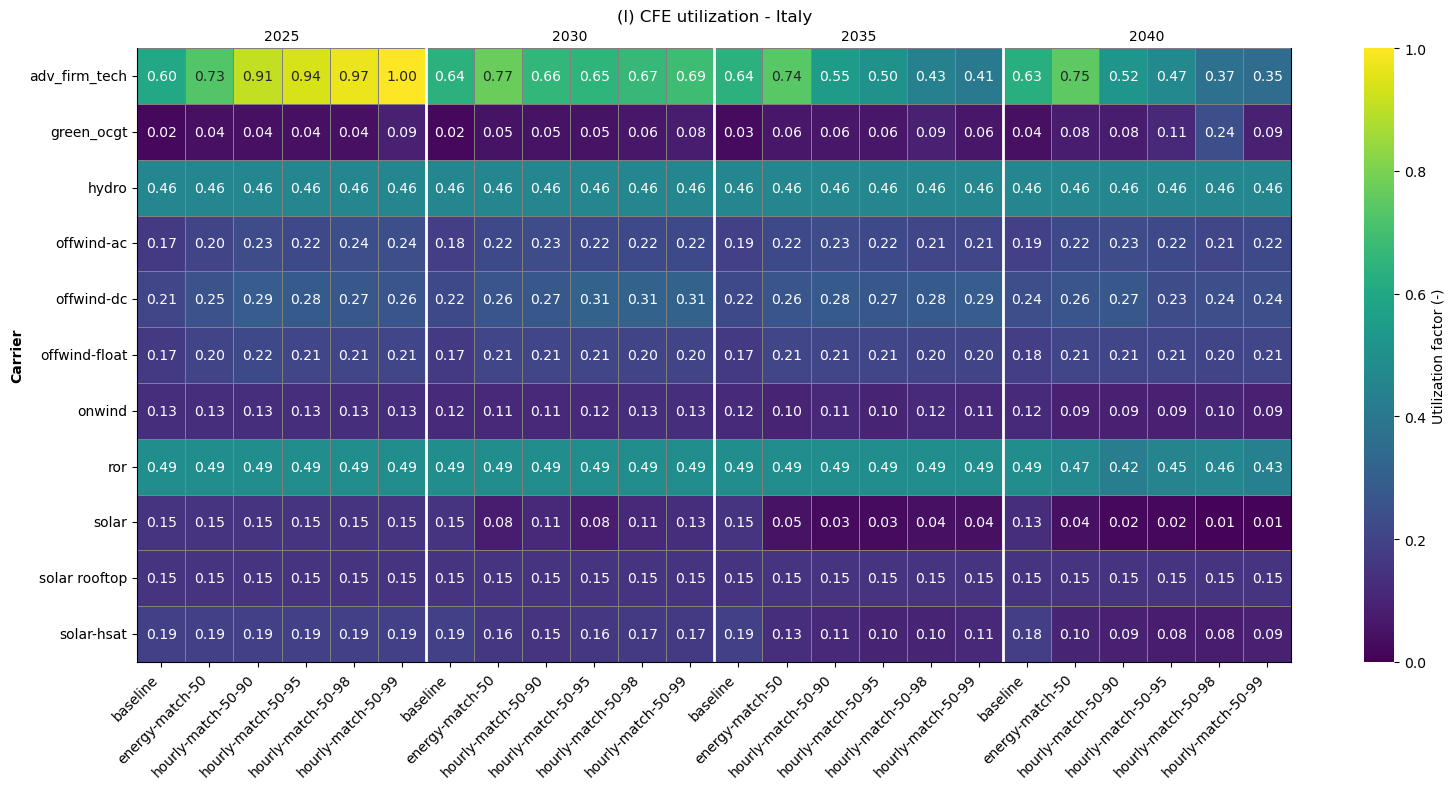

Results saved to figures/time_comparison/country-50/Italy/results-Italy.csv


In [39]:
save_fig = True
df, colors = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier","country1"])
df["color"] = colors
countries = df.index.get_level_values("country1").unique().drop("")
countries = ["IT",
             "DE",] #test
for cc in sorted(countries):

    dfs_list = []
    cc_name = country_converter.CountryConverter().convert(cc, to="short_name")
    fig_path = f"figures/time_comparison/country-{CI_share}/{cc_name}"
    print(f"-------------------------------------Analyzing {cc_name}")

    # (a) Energy mix
    results = "Energy mix"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier","country1"])
    df["color"] = colors
    df = df[
        df.index.get_level_values("bus_carrier").isin(["AC",
                                                    "low voltage",
                                                    ])
        & ~df.index.get_level_values("carrier").isin(["AC",
                                                    "DC",
                                                    "electricity",
                                                    "low voltage",
                                                    "electricity distribution grid",
                                                    "BEV charger",
                                                    "home battery charger",
                                                    "home battery discharger",
                                                    ])
        & df.index.get_level_values("country1").isin([cc])
    ]

    df = df.groupby("carrier").apply(sum_except_color)
    df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e6

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()

    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)


    # (b) Energy mix - GO Market
    results = "Energy mix - GO Market"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df_GoO = df_networks[df_networks.index.get_level_values("scenario") != "baseline"]
    df, colors = get_stats_all(df_GoO["GoO"], "energy_balance", groupby=["carrier", "country1"])
    df["color"] = colors
    df = df[(df.index.get_level_values("carrier") != "GoO")
             & df.index.get_level_values("country1").isin([cc])
            ].groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e6

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (c) Capacity mix
    results = "Capacity mix"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier", "country1"])
    df["color"] = colors

    df = df[
        ~df.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
        & ~df.index.get_level_values("carrier").isin(["AC","DC","electricity distribution grid","low voltage"] + list(grouping_storage.keys()))
        & ~df.index.get_level_values("component").isin(["Store","StorageUnit"])
        & df.index.get_level_values("country1").isin([cc])
    ]

    df = df.loc[~df.index.isin([("Generator","coal","coal"),("Generator","gas","gas")])]
    df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e3

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (d) Capacity mix - new technologies (proxy of GO Market)
    results = "Capacity mix - new technologies (proxy of GO Market)"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier","build_year", "country1"])

    for c in df.columns:
        scenario_year = int(c[0])
        df.loc[df.index.get_level_values("build_year") != scenario_year,c] = 0

    df["color"] = colors

    df = df[
        ~df.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
        & ~df.index.get_level_values("carrier").isin(["AC","DC","electricity distribution grid","low voltage"] + list(grouping_storage.keys()))
        & ~df.index.get_level_values("component").isin(["Store","StorageUnit"])
        & df.index.get_level_values("country1").isin([cc])
    ]

    df = df.loc[~df.index.isin([("Generator","coal","coal"),("Generator","gas","gas")])]
    df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e3

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (e) Storage in GO Market - Energy capacity (stores)
    results = "Storage in GO Market - Energy capacity"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier", "country1"])
    df["color"] = colors

    df = df[
        df.index.get_level_values("component").isin(["Store"])
        & df.index.get_level_values("carrier").isin(list(grouping_storage.keys()))
        & ~df.index.get_level_values("carrier").isin(['EV battery','home battery'])
        & df.index.get_level_values("country1").isin([cc])
    ]

    df = df.groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e3

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (e) Storage in GO Market - Power capacity (links)
    results = "Storage in GO Market - Power capacity"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier", "country1"])
    df["color"] = colors

    df = df[
        df.index.get_level_values("component").isin(["Link"])
        & df.index.get_level_values("carrier").isin(list(grouping_storage.keys()))
        & ~df.index.get_level_values("carrier").isin(['BEV charger','li-ion discharger','iron-air discharger','home battery charger','home battery discharger'])
        & df.index.get_level_values("country1").isin([cc])
    ]

    df = df.groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e3

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # # (f) Total system cost
    # title_fig = "(f) Total system cost - {cc_name}"
    # df, _ = get_stats_all(df_networks["network"], "system_cost", groupby=["carrier","country1"])
    # df = df[df.index.get_level_values("country1").isin([cc])]
    # df = df.rename(index=rename_map).groupby("carrier").sum()
    # df = df / 1e9 # to Billion

    # colors = [category_colors[i] for i in df.index]

    # ax = plot_bar(df, colors, ylabel="Total system cost (b€)", title=f"(f) {cc_name} Total System Cost")
    # if save_fig:
    #     os.makedirs(fig_path, exist_ok=True)
    #     ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    # (g) Total system cost - new technologies (proxy of GO Market)
    results = "Total system cost - new technologies (proxy of GO Market)"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, _ = get_stats_all(df_networks["network"], "system_cost", groupby=["carrier","build_year", "country1"])
    df = df[df.index.get_level_values("country1").isin([cc])]

    for c in df.columns:
        scenario_year = int(c[0])
        df.loc[df.index.get_level_values("build_year") != scenario_year,c] = 0

    df = df.rename(index=rename_map).groupby("carrier").sum()
    df = df / 1e9 # to Billion

    colors = [category_colors[i] for i in df.index]

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (h) GO Market revenue by technology
    results = "GO Market revenue by technology"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df_GoO = df_networks[df_networks.index.get_level_values("scenario") != "baseline"]
    df, colors = get_stats_all(df_GoO["GoO"], "revenue", groupby=["carrier","country1"])
    df["color"] = colors
    df = df[(df.index.get_level_values("carrier") != "GoO")
            & (df.index.get_level_values("country1").isin([cc]))
            ].groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e9 # to Billion

    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (i) Marginal Price of GoO Consumers
    results = "Marginal price of GoO consumers"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, _ = get_stats_prices(df_networks["network"])
    
    keywords = ["GO Demand", "low voltage"]
    pattern = "|".join(keywords)
    
    df = df[
        df.index.str.extract(f"({pattern})", expand=False).isin(keywords)
        & df.index.map(n.buses.country).isin([cc])
        ]
    
    df.index = df.index.map(n.buses.carrier)
    df = df.groupby(df.index).sum()
    colors = df.index.map(n.carriers.color)
    
    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (j) CO2 emissions
    results = "CO2 emissions"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier","name"])
    df["color"] = colors
    
    df = df[
        df.index.get_level_values("bus_carrier").isin(["co2"])
        & df.index.get_level_values("component").isin(["Link"])
        & df.index.get_level_values("name").str.contains(cc)
    ]
    df = df.groupby("carrier").apply(sum_except_color)
    
    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e6 # to MtC02
    
    ax = plot_bar(df, colors, ylabel=y_label, title=title_fig)
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df.copy()
        df_csv.index = pd.MultiIndex.from_product([[letter + " " + results], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (k) CFE curtailment
    results = "CFE curtailment"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    df, colors = get_stats_all(df_networks["network"], "curtailment", groupby=["carrier","bus_carrier", "name"])
    df["color"] = colors

    df = df[
        df.index.get_level_values("bus_carrier").isin(["AC",
                                                    "low voltage",
                                                    ])
        & ~df.index.get_level_values("carrier").isin(["AC",
                                                    "DC",
                                                    "electricity",
                                                    "low voltage",
                                                    "electricity distribution grid",
                                                    "BEV charger",
                                                    "home battery charger",
                                                    "home battery discharger",
                                                    "PHS",
                                                    "iron-air",
                                                    "li-ion",
                                                    "H2 Store",
                                                    ])
        & df.index.get_level_values("name").str.contains(cc)
    ]

    df = df.groupby("carrier").apply(sum_except_color)
    df = df.rename(index=grouping_storage).groupby("carrier").apply(sum_except_color)

    colors = df["color"]
    df = df.drop("color", axis=1)
    df = df / 1e6

    # derive total curtailment and curtailment shares
    df_curt = df.copy()
    df_curt.loc["total"] = df_curt.sum(axis=0)

    df_gen, colors_gen = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier","country1"])

    df_gen = df_gen[
        df_gen.index.get_level_values("bus_carrier").isin(["AC",
                                                    "low voltage",
                                                    ])
        & df_gen.index.get_level_values("carrier").isin(df_curt.index)
        & df_gen.index.get_level_values("country1").isin([cc])
    ]

    df_gen = df_gen.groupby("carrier").sum()
    df_gen = df_gen / 1e6
    df_gen.loc["total"] = df_gen.sum(axis=0)

    df_curt_share = df_curt / (df_gen + df_curt)

    # Use new function with share line
    ax, ax_share = plot_bar_with_share(df, colors, df_curt_share, 
                                        ylabel=y_label, 
                                        ylabel_share="Curtailment share (%)",
                                        title=f"{title_fig}")
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

    #display(round(df_curt_share.T,2))

    cmap_style = 'viridis'
    #cmap_style = 'RdYlGn'
    cmap = plt.cm.get_cmap(cmap_style)
    norm = mcolors.Normalize(vmin=0, vmax=1)
    #display(df_curt_share.T.style.background_gradient(cmap=cmap, vmin=0, vmax=1).format("{:.2f}"))

    ax = plot_heatmap(df_curt_share, title_fig, cmap_style, legend_title = "Curtailment share (-)")
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig} table.png", dpi=300, bbox_inches="tight")

        df_csv = df_curt.copy()
        df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)


        df_csv = df_curt_share.copy()
        df_csv.index = pd.MultiIndex.from_product([[title_fig], ["Curtailment share (-)"], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # (l) CFE utilization
    results = "CFE utilization"
    letter = plot_formats[results]['letter']
    y_label = plot_formats[results]['y_label']
    title_fig = letter + " " + results + " - " + cc_name

    # Net yearly generation
    df_gen, _ = get_stats_all(df_networks["network"], "energy_balance", groupby=["carrier","bus_carrier","country1"])

    df_gen = df_gen[
        df_gen.index.get_level_values("bus_carrier").isin(["AC",
                                                    "low voltage",
                                                    ])
        & df_gen.index.get_level_values("carrier").isin(clean_carriers)
        & df_gen.index.get_level_values("country1").isin([cc])
    ].groupby("carrier").sum()

    # Nominal yearly generation
    df_cap, _ = get_stats_all(df_networks["network"], "optimal_capacity", groupby=["carrier","bus_carrier","country1"])

    df_cap = df_cap[
        ~df_cap.index.get_level_values("bus_carrier").isin(["GoO","co2","co2 stored"])
        & df_cap.index.get_level_values("carrier").isin(clean_carriers)
        & df_cap.index.get_level_values("country1").isin([cc])
    ].groupby("carrier").sum()

    # Calculate utilization rate
    cmap_style = 'viridis'
    #cmap_style = 'RdYlGn'
    cmap = plt.cm.get_cmap(cmap_style)
    norm = mcolors.Normalize(vmin=0, vmax=1)
    df_use = round(df_gen / (df_cap * 8760), 2)
    #display(df_use.T.style.background_gradient(cmap=cmap, vmin=0, vmax=1).format("{:.2f}"))

    ax = plot_heatmap(df_use, title_fig, cmap_style, legend_title = "Utilization factor (-)")
    plt.show()
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

        df_csv = df_use.copy()
        df_csv.index = pd.MultiIndex.from_product([[title_fig], [y_label], df_csv.index], names=['Results', 'y_label', 'carrier'])
        dfs_list.append(df_csv)

    # SAVE .csv
    csv_path_results = os.path.join(fig_path, f"results-{cc_name}.csv")
    os.makedirs(fig_path, exist_ok=True)
    dfs_csv = pd.concat(dfs_list, axis = 0)
    dfs_csv.to_csv(csv_path_results)
    print(f"Results saved to {csv_path_results}")    
